# MRI 脑体素分割 - 使用Kolmogorov-Arnold网络(KAN)

这个笔记本演示如何使用KAN (Kolmogorov-Arnold Networks)替代传统MLP进行MRI脑体素分割。KAN是一种新型神经网络结构，它使用可学习的激活函数来提高性能和可解释性。

我们将使用与原始MLP相同的MRI数据，但应用KAN架构，并比较其性能。

In [1]:
# 导入KAN和其他必要的库
from fastkan import *
# from efficient_kan import *
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import pandas as pd
from IPython import display
import h5py
import scipy.io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import logging
import sys
import os
import torch
import glob
import random
from tqdm import tqdm
from sklearn.utils import shuffle
from datetime import datetime
import json
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# 设置matplotlib显示中文
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = True

print("所有库导入成功！")

所有库导入成功！


In [2]:
# 设置计算设备
if torch.cuda.is_available():
    device = torch.device('cuda')
    # 获取GPU信息
    gpu_name = torch.cuda.get_device_name(0)
    gpu_count = torch.cuda.device_count()
    print(f"使用设备: {device} ({gpu_name})")
    print(f"可用GPU数量: {gpu_count}")
    !nvidia-smi
else:
    device = torch.device('cpu')
    print(f"使用设备: {device}")


使用设备: cuda (NVIDIA RTX A6000)
可用GPU数量: 1
Tue Mar 11 13:53:51 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:4F:00.0 Off |                  Off |
| 30%   25C    P8             30W /  300W |   38848MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+------

In [3]:

# ---------------- 集中管理所有超参数和配置 ----------------
class ConfigManager:
    def __init__(self):
        # 路径配置
        self.output_path = '/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/'
        self.export_path = '/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/kan_models_binary/'
        self.train_label_dir = '/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/train_set_by_label'
        self.val_label_dir = '/home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/val_set_by_label'
        self.results_dir = os.path.join(self.export_path, 'results')
        
        # 数据集配置
        self.num_labels = 102
        self.feature_dim = 341
        
        # 训练参数 - 添加缺失的batch_size和learning_rate属性
        self.batch_size = 64         # Adam优化器的批量大小
        self.learning_rate = 0.3         # Adam优化器的学习率

        # 数据采样和增强配置
        self.negative_ratio = 1         # 训练集负样本与正样本的比例K
        self.val_negative_ratio = 50     # 验证集负样本与正样本的比例K (新增)
        self.val_size = 5000             # 验证集的大小限制（每个标签）
        self.enable_augmentation = True # 是否启用小类别增强
        self.min_voxel_threshold = 5000 # 体素数量阈值，低于此值的类别将被视为小类别
        self.enable_noise_augmentation = True  # 启用噪声增强
        self.noise_scale = 0.01         # 噪声强度系数
        self.enable_oversampling = True # 启用过采样
        self.oversampling_ratio = 2.0   # 过采样倍数
        self.noise_applicable_features = [
            (0, 15),     # 扩散MRI相关指标 (0-14)
            (225, 229)   # MT & CEST信号 (225-228)
        ]
        
        # 新增: 批次采样控制参数
        self.ensure_batch_ratio = True   # 是否在每个批次中强制保持正负样本比例
        self.allow_sample_repetition = False  # 是否允许在一个epoch内重复采样
        
        # 新增: 网格和训练步骤控制参数
        self.grid_extension_scale = 1.0  # 网格扩展比例因子 (1.0 = 全部使用, 0.5 = 使用一半)
        self.training_steps_scale = 1.0  # 训练步数比例因子
        self.enable_adaptive_steps = True  # 是否根据数据分布自适应调整步数
        self.min_steps_per_grid = 5      # 每个网格的最小步数，即使有自适应调整
        
        # KAN网络结构 - 修改为二分类输出(1)
        self.network_structure = [341, 1024, 892,512,256,64,32, 1]  # [输入维度, 隐藏层1, 隐藏层2, 输出维度(1)]
        
        # 网格策略设计 - 指数型增长
        self.n_grid_extensions = 40     # 总共进行80次网格扩展
        self.initial_grid = 3           # 从网格大小3开始
        self.max_grid = 60              # 最大网格大小100
        self.grid_extension_scale = 1.0  # 网格扩展比例因子 (1.0 = 全部使用, 0.5 = 使用一半)
        self.training_steps_scale = 1.0  # 训练步数比例因子
        self.enable_adaptive_steps = False  # 是否根据数据分布自适应调整步数
        self.min_steps_per_grid = 5      # 每个网格的最小步数，即使有自适应调整

        # 初始化网格序列和相关参数
        self._setup_grid_strategy()
        
        # 确保目录存在
        self._ensure_directories()


        # 训练控制参数
        self.use_early_stopping = True  # 是否启用早停
        self.early_stopping_patience = 1000  # 早停耐心值
        self.early_stopping_min_delta = 0.001  # 最小改进阈值
        self.monitor_metric = 'auc_pr'  # 监控指标，可选 'val_loss' 或 'val_f1'

        # 验证集配置
        self.val_negative_ratio = 100     # 验证集负样本与正样本的比例K
        self.val_size = 5000             # 验证集正样本的大小限制（每个标签）
        self.use_all_labels_for_val = True  # 使用所有其他标签作为验证集负样本
        self.min_samples_per_label = 1      # 新增: 每个标签至少贡献的样本数
        self.max_samples_per_label = 500    # 新增: 每个标签最多贡献的样本数
        self.val_sample_strategy = 'proportional'  # 新增: 验证集采样策略 ['balanced', 'proportional', 'adaptive']

        
    def _setup_grid_strategy(self):
        """设置网格扩展策略"""
        # 根据比例因子计算有效的网格扩展次数
        effective_extensions = max(1, int(self.n_grid_extensions * self.grid_extension_scale))
        
        # 生成指数增长的网格序列
        self.grid_sequence = [int(self.initial_grid * (self.max_grid/self.initial_grid)**(i/(effective_extensions-1))) 
                            for i in range(effective_extensions)]
        # 去重并排序
        self.grid_sequence = sorted(list(set(self.grid_sequence)))
        # 确保最后一个网格大小不超过最大值
        if self.grid_sequence[-1] > self.max_grid:
            self.grid_sequence[-1] = self.max_grid
        
        # 将网格序列分为三个主要阶段
        phase1_end = len(self.grid_sequence) // 3  # 第1阶段结束索引
        phase2_end = 2 * len(self.grid_sequence) // 3  # 第2阶段结束索引
        
        # 三个主要阶段的网格序列
        self.phase_grid_sequences = [
            self.grid_sequence[:phase1_end+1],  # 第1阶段网格序列
            self.grid_sequence[phase1_end+1:phase2_end+1],  # 第2阶段网格序列
            self.grid_sequence[phase2_end+1:]  # 第3阶段网格序列
        ]
        
        # 基础每个阶段的训练步数（将被training_steps_scale调整）
        self.base_steps_per_phase = {
            0: 50,  # 第1阶段每个网格点训练90步
            1: 30,  # 第2阶段每个网格点训练60步
            2: 20   # 第3阶段每个网格点训练50步
        }
        
        # 应用训练步数比例因子
        self.steps_per_phase = {
            phase: max(self.min_steps_per_grid, int(steps * self.training_steps_scale))
            for phase, steps in self.base_steps_per_phase.items()
        }
        
        # 计算总训练步数
        self.total_steps = sum(self.steps_per_phase[i] * len(self.phase_grid_sequences[i]) for i in range(3))
    
    def set_grid_extension_scale(self, scale):
        """设置网格扩展比例因子并重新计算网格序列"""
        self.grid_extension_scale = max(0.1, min(1.0, scale))  # 限制在0.1到1.0之间
        self._setup_grid_strategy()
        print(f"网格扩展比例设置为{self.grid_extension_scale}，将使用{len(self.grid_sequence)}个网格点")
        return self
    
    def set_training_steps_scale(self, scale):
        """设置训练步数比例因子并重新计算步数"""
        self.training_steps_scale = max(0.1, scale)  # 最小限制为0.1
        self._setup_grid_strategy()
        print(f"训练步数比例设置为{self.training_steps_scale}")
        print(f"第1阶段: {self.steps_per_phase[0]}步/网格, 第2阶段: {self.steps_per_phase[1]}步/网格, 第3阶段: {self.steps_per_phase[2]}步/网格")
        return self
    
    def adapt_training_steps(self, dataset):
        """
        根据数据集分布自适应调整训练步数
        
        参数:
            dataset: 包含训练数据的数据集字典
        """
        if not self.enable_adaptive_steps:
            print("自适应步数已禁用，使用配置的步数")
            return
            
        try:
            # 获取训练集基本信息
            train_data = dataset['train_data']
            train_label = dataset['train_label']
            total_samples = len(train_data)
            
            # 获取正样本和负样本数量
            positive_count = np.sum(train_label == 1)
            negative_count = np.sum(train_label == 0)
            
            # 检查是否有足够的数据进行基于比例的采样
            total_ratio = self.negative_ratio + 1  # 总比例 (例如, 1:3比例意味着total_ratio = 4)
            batch_positive_ratio = 1 / total_ratio
            
            # 计算每个批次中预期的正负样本数量
            expected_pos_per_batch = int(self.batch_size * batch_positive_ratio)
            expected_neg_per_batch = self.batch_size - expected_pos_per_batch
            
            # 计算我们可以按照期望比例创建的完整批次数量
            max_batches_from_positives = positive_count / expected_pos_per_batch
            max_batches_from_negatives = negative_count / expected_neg_per_batch
            max_complete_batches = min(max_batches_from_positives, max_batches_from_negatives)
            
            # 打印详细的训练集信息
            print(f"\n{'='*80}")
            print(f"训练集详细信息与自适应训练步数分析:")
            print(f"{'='*80}")
            print(f"训练集总样本数: {total_samples}")
            print(f"  - 正样本数量: {positive_count} ({positive_count/total_samples*100:.2f}%)")
            print(f"  - 负样本数量: {negative_count} ({negative_count/total_samples*100:.2f}%)")
            print(f"  - 实际负正比例: {negative_count/positive_count:.2f}:1 (配置值: {self.negative_ratio}:1)")
            print(f"\n批次采样配置:")
            print(f"  - 批次大小: {self.batch_size}")
            print(f"  - 每个批次期望正样本数: {expected_pos_per_batch} ({batch_positive_ratio*100:.1f}%)")
            print(f"  - 每个批次期望负样本数: {expected_neg_per_batch} ({(1-batch_positive_ratio)*100:.1f}%)")
            print(f"  - 维持比例的情况下，最多可构建完整批次数: {int(max_complete_batches)}")
            
            # 检查每个批次的正样本数量是否足够
            if expected_pos_per_batch < 10:
                print(f"\n警告: 每个批次的预期正样本数量较少 ({expected_pos_per_batch})，可能影响训练质量")
                print(f"建议: 考虑减小批次大小或增加数据增强")
            
            # 计算平均每批次样本数
            avg_samples_per_batch = total_samples / self.total_steps if self.total_steps > 0 else 0
            
            # 打印当前训练步数信息
            print(f"\n当前训练步数配置:")
            print(f"  - 总训练步数: {self.total_steps}")
            print(f"  - 第1阶段: {self.steps_per_phase[0]}步/网格, 第2阶段: {self.steps_per_phase[1]}步/网格, 第3阶段: {self.steps_per_phase[2]}步/网格")
            print(f"  - 平均每批次样本数: {avg_samples_per_batch:.1f}")
            
            # 原始总步数
            original_total = self.total_steps
            
            # 根据可用数据计算调整因子
            ideal_batches = self.total_steps
            adjustment_factor = min(1.0, max_complete_batches / ideal_batches)
            
            # 输出自适应调整分析
            print(f"\n自适应步数调整分析:")
            print(f"  - 理想批次数: {ideal_batches}")
            print(f"  - 可用完整批次数: {int(max_complete_batches)}")
            print(f"  - 调整因子: {adjustment_factor:.3f}")
            
            if adjustment_factor < 0.9:  # 只有在需要显著减少时才调整
                # 应用调整到steps_per_phase
                updated_steps = {}
                for phase in range(3):
                    original_steps = self.base_steps_per_phase[phase] * self.training_steps_scale
                    adjusted_steps = max(self.min_steps_per_grid, int(original_steps * adjustment_factor))
                    updated_steps[phase] = adjusted_steps
                
                self.steps_per_phase = updated_steps
                
                # 重新计算总步数
                self.total_steps = sum(self.steps_per_phase[i] * len(self.phase_grid_sequences[i]) for i in range(3))
                
                print(f"  - 训练步数已调整: {original_total} → {self.total_steps} (减少 {original_total - self.total_steps} 步, {(1-adjustment_factor)*100:.1f}%)")
                print(f"  - 更新后的各阶段步数: 第1阶段: {self.steps_per_phase[0]}, 第2阶段: {self.steps_per_phase[1]}, 第3阶段: {self.steps_per_phase[2]}")
                
                # 计算调整后平均每步使用的训练样本比例
                adjusted_sample_usage_ratio = (self.total_steps * self.batch_size) / total_samples
                print(f"  - 调整后样本使用比例: {adjusted_sample_usage_ratio:.2f}x (值>1表示样本可能被重复使用)")
            else:
                print(f"  - 无需调整，训练步数保持: {self.total_steps}")
                # 计算当前平均每步使用的训练样本比例
                current_sample_usage_ratio = (self.total_steps * self.batch_size) / total_samples
                print(f"  - 当前样本使用比例: {current_sample_usage_ratio:.2f}x (值>1表示样本可能被重复使用)")
            
            print(f"\n{'='*80}")
            
        except Exception as e:
            print(f"自适应调整训练步数时出错: {str(e)}")
            import traceback
            traceback.print_exc()
    
    def enable_early_stopping(self, enable=True):
        """启用或禁用早停机制"""
        self.use_early_stopping = enable
        print(f"早停机制已{'启用' if enable else '禁用'}")
        return self
    
    def _ensure_directories(self):
        """确保所有需要的目录都存在"""
        os.makedirs(self.export_path, exist_ok=True)
        os.makedirs(self.results_dir, exist_ok=True)
    
    def print_config(self):
        """打印配置信息"""
        print(f"KAN网络结构: {self.network_structure}")
        print(f"参数设置完成，二分类训练, 批量大小: {self.batch_size}")
        print(f"学习率: {self.learning_rate}, 总训练步数: {self.total_steps}")
        print(f"网格扩展次数: {len(self.grid_sequence)}")
        print(f"网格扩展序列: {self.grid_sequence}")
        print(f"\n指数网格训练策略:")
        print(f"  阶段1 (网格 {self.grid_sequence[0]}-{self.grid_sequence[len(self.phase_grid_sequences[0])-1]}): "
             f"每个网格点训练 {self.steps_per_phase[0]} 步")
        print(f"  阶段2 (网格 {self.grid_sequence[len(self.phase_grid_sequences[0])]}-"
             f"{self.grid_sequence[len(self.phase_grid_sequences[0])+len(self.phase_grid_sequences[1])-1]}): "
             f"每个网格点训练 {self.steps_per_phase[1]} 步")
        print(f"  阶段3 (网格 {self.grid_sequence[len(self.phase_grid_sequences[0])+len(self.phase_grid_sequences[1])]}-"
             f"{self.grid_sequence[-1]}): 每个网格点训练 {self.steps_per_phase[2]} 步")
        print(f"\n数据采样配置:")
        print(f"  训练集负/正样本比例: {self.negative_ratio}:1")
        print(f"  验证集负/正样本比例: {self.val_negative_ratio}:1")
        print(f"  验证集大小限制: {self.val_size} 样本/标签")
        if hasattr(self, 'ensure_batch_ratio'):
            print(f"  批次负/正样本比例保持: {'启用' if self.ensure_batch_ratio else '禁用'}")
            if self.ensure_batch_ratio:
                print(f"  允许样本重复: {'是' if self.allow_sample_repetition else '否'}")




# 创建全局配置实例
config = ConfigManager()

# ---------------- 数据增强函数 ----------------
def apply_gaussian_noise(data, noise_scale=0.01, applicable_features=None):
    """
    对特定特征维度应用高斯噪声
    
    参数:
        data: 输入数据，形状为(n_samples, n_features)
        noise_scale: 噪声强度系数
        applicable_features: 可应用噪声的特征索引范围列表，如[(0,15), (225,229)]
    
    返回:
        增强后的数据
    """
    # 复制原始数据，避免修改原数据
    augmented_data = data.copy()
    
    # 如果没有指定可应用噪声的特征，默认对所有特征应用
    if applicable_features is None:
        # 计算数据标准差
        std_dev = np.std(data, axis=0)
        # 生成随机噪声
        noise = np.random.normal(0, noise_scale * std_dev, data.shape)
        # 应用噪声
        augmented_data = data + noise
    else:
        # 仅对指定的特征索引范围应用噪声
        for start_idx, end_idx in applicable_features:
            # 选择特征子集
            feature_subset = data[:, start_idx:end_idx]
            # 计算该子集的标准差
            std_dev = np.std(feature_subset, axis=0)
            # 生成随机噪声
            noise = np.random.normal(0, noise_scale * std_dev, feature_subset.shape)
            # 应用噪声
            augmented_data[:, start_idx:end_idx] = feature_subset + noise
    
    return augmented_data

# ---------------- 模型保存和加载函数 ----------------
def save_model_comprehensive(model, folder_path, config, label_id=None, add_timestamp=True):
    """
    综合性保存KAN模型：同时保存完整模型和权重，以及所有超参数
    
    参数:
    model: KAN模型实例
    folder_path: 保存文件夹的基础路径
    config: 配置对象，包含超参数
    label_id: 当前训练的标签ID
    add_timestamp: 是否添加时间戳到文件夹名称
    
    返回:
    保存的路径
    """
    try:
        # 获取当前网格大小
        current_grid = get_grid_size(model)
        
        # 添加时间戳和标签信息到文件夹名称
        if add_timestamp:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            if label_id is not None:
                folder_path = f"{folder_path}_label{label_id}_grid{current_grid}_{timestamp}"
            else:
                folder_path = f"{folder_path}_grid{current_grid}_{timestamp}"
        
        # 创建目录
        os.makedirs(folder_path, exist_ok=True)
        
        # 1. 保存完整模型（方法一）
        model_path = os.path.join(folder_path, 'complete_model.pt')
        torch.save(model, model_path)
        
        # 2. 保存模型权重（方法二）
        weights_path = os.path.join(folder_path, 'weights.pt')
        torch.save(model.state_dict(), weights_path)
        
        # 获取模型实际结构信息
        actual_width = []
        for layer in model.layers:
            if hasattr(layer, 'base_linear') and hasattr(layer.base_linear, 'weight'):
                if layer.base_linear.weight.shape[0] == 1:  # 输出层
                    actual_width.append(1)
                else:
                    actual_width.append(layer.base_linear.weight.shape[0])
        
        # 推断输入维度
        if len(model.layers) > 0 and hasattr(model.layers[0], 'base_linear'):
            input_dim = model.layers[0].base_linear.weight.shape[1]
            actual_width.insert(0, input_dim)
        
        # 3. 保存详细配置信息
        model_config = {
            # 模型结构信息
            'width': actual_width,
            'grid': current_grid, 
            'k': model.k if hasattr(model, 'k') else 3,
            'input_dim': input_dim if 'input_dim' in locals() else 341,
            'output_dim': 1,  # 二分类
            
            # 标识信息
            'saved_at': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'label_id': label_id,
            'binary_mode': True,
            
            # 训练超参数
            'batch_size': config.batch_size,
            'learning_rate': config.learning_rate,
            'total_steps': config.total_steps,
            'network_structure': config.network_structure,
            'grid_sequence': config.grid_sequence,
            'phase_grid_sequences': [seq.tolist() if isinstance(seq, np.ndarray) else seq 
                                     for seq in config.phase_grid_sequences] 
                                    if hasattr(config, 'phase_grid_sequences') else None,
            'steps_per_phase': config.steps_per_phase,
            
            # 数据配置
            'negative_ratio': config.negative_ratio if hasattr(config, 'negative_ratio') else None,
            'enable_augmentation': config.enable_augmentation if hasattr(config, 'enable_augmentation') else None,
            'noise_scale': config.noise_scale if hasattr(config, 'noise_scale') else None,
            'oversampling_ratio': config.oversampling_ratio if hasattr(config, 'oversampling_ratio') else None
        }
        
        # 保存配置
        with open(os.path.join(folder_path, 'config.json'), 'w') as f:
            # 处理无法序列化的字段
            serializable_config = {}
            for k, v in model_config.items():
                try:
                    json.dumps({k: v})  # 测试是否可序列化
                    serializable_config[k] = v
                except:
                    serializable_config[k] = str(v)  # 转为字符串
            
            json.dump(serializable_config, f, indent=4)
        
        # 4. 创建详细的README文件
        with open(os.path.join(folder_path, 'README.txt'), 'w') as f:
            f.write(f"# KAN Binary Classification Model for Label {label_id}\n\n")
            f.write(f"Saved at: {model_config['saved_at']}\n\n")
            
            f.write("## Model Architecture\n")
            f.write(f"Network Structure: {actual_width}\n")
            f.write(f"Grid Size: {current_grid}\n")
            f.write(f"K value: {model_config['k']}\n")
            f.write(f"Input dimension: {model_config['input_dim']}\n")
            f.write(f"Output: Binary (1)\n\n")
            
            f.write("## Training Parameters\n")
            f.write(f"Batch Size: {config.batch_size}\n")
            f.write(f"Learning Rate: {config.learning_rate}\n")
            f.write(f"Total Steps: {config.total_steps}\n")
            f.write(f"Grid Extensions: {len(config.grid_sequence)}\n")
            f.write(f"Grid Sequence: {config.grid_sequence}\n\n")
            
            f.write("## Grid Training Strategy\n")
            for i, (seq, steps) in enumerate(zip(config.phase_grid_sequences, 
                                              [config.steps_per_phase[i] for i in range(3)])):
                f.write(f"  Phase {i+1}: Grid {seq[0]}-{seq[-1]}, {steps} steps per grid\n")
            
            f.write("\n## Data Configuration\n")
            if hasattr(config, 'negative_ratio'):
                f.write(f"Negative/Positive Ratio: {config.negative_ratio}\n")
            if hasattr(config, 'enable_augmentation'):
                f.write(f"Data Augmentation: {'Enabled' if config.enable_augmentation else 'Disabled'}\n")
                if config.enable_augmentation:
                    if hasattr(config, 'noise_scale'):
                        f.write(f"  Noise Scale: {config.noise_scale}\n")
                    if hasattr(config, 'oversampling_ratio'):
                        f.write(f"  Oversampling Ratio: {config.oversampling_ratio}x\n")
        
        print(f"模型已全面保存到: {folder_path}")
        return folder_path
    
    except Exception as e:
        print(f"保存模型失败: {str(e)}")
        import traceback
        traceback.print_exc()
        return None
    

def load_model_comprehensive(folder_path, method='auto', device=None):
    """
    综合性加载KAN模型：可以选择加载方法
    
    参数:
    folder_path: 模型文件夹路径
    method: 加载方法，'complete'=加载完整模型，'weights'=重建模型并加载权重，
            'auto'=自动选择最佳方法
    device: 计算设备
    
    返回:
    model: 加载的KAN模型
    config: 模型配置
    """
    try:
        if device is None:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # 加载配置
        with open(os.path.join(folder_path, 'config.json'), 'r') as f:
            config = json.load(f)
        
        # 确定使用哪种加载方法
        if method == 'auto':
            # 检查是否存在完整模型文件
            if os.path.exists(os.path.join(folder_path, 'complete_model.pt')):
                method = 'complete'
            else:
                method = 'weights'
        
        # 方法1: 加载完整模型
        if method == 'complete':
            model_path = os.path.join(folder_path, 'complete_model.pt')
            if os.path.exists(model_path):
                try:
                    # 添加这行来允许加载FastKAN类
                    torch.serialization.add_safe_globals(['fastkan.fastkan.FastKAN'])
                    # 或者使用这种方式明确禁用安全检查（仅在信任源时使用）
                    model = torch.load(model_path, map_location=device, weights_only=False)
                    print(f"成功加载完整模型!")
                    return model, config
                except Exception as e:
                    print(f"加载完整模型失败: {str(e)}，尝试使用权重加载方法")
                    method = 'weights'  
        # 方法2: 重建模型并加载权重
        if method == 'weights':
            # 获取模型结构
            network_width = config.get('width')
            if not network_width:
                # 尝试从config中获取网络结构
                network_width = config.get('network_structure', [341, 128, 56, 1])
            
            # 获取网格大小
            grid_size = config.get('grid', 3)
            
            # 创建模型
            try:
                from fastkan import FastKAN
                model = FastKAN(
                    layers_hidden=network_width,
                    num_grids=grid_size
                )
                
                # 加载权重
                weights_path = os.path.join(folder_path, 'weights.pt')
                model.load_state_dict(torch.load(weights_path, map_location=device))
                model = model.to(device)
                
                print(f"成功通过权重重建模型!")
            except Exception as e:
                print(f"通过权重重建模型失败: {str(e)}")
                return None, config
        
        # 显示模型信息
        label_id = config.get('label_id', 'Unknown')
        saved_at = config.get('saved_at', 'Unknown')
        print(f"模型标签ID: {label_id}, 保存时间: {saved_at}")
        print(f"网络结构: {config.get('width', 'Unknown')}")
        print(f"网格大小: {config.get('grid', 'Unknown')}")
        print(f"训练参数: 批量大小={config.get('batch_size', 'Unknown')}, "
              f"学习率={config.get('learning_rate', 'Unknown')}")
        
        return model, config
    
    except Exception as e:
        print(f"加载模型失败: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None


def find_latest_model(base_folder, label_id=None):
    """
    查找指定标签ID的最新模型文件夹
    
    参数:
    base_folder: 基础文件夹路径
    label_id: 标签ID，如果为None则查找所有最新模型
    
    返回:
    最新模型的完整路径，如果没有找到则返回None
    """
    try:
        # 获取所有匹配前缀的文件夹
        if label_id is not None:
            matching_folders = [f for f in os.listdir(base_folder) 
                               if os.path.isdir(os.path.join(base_folder, f)) 
                               and f"_label{label_id}_" in f]
        else:
            matching_folders = [f for f in os.listdir(base_folder) 
                               if os.path.isdir(os.path.join(base_folder, f))]
        
        if not matching_folders:
            if label_id is not None:
                print(f"未找到标签ID '{label_id}' 的模型文件夹")
            else:
                print(f"未找到任何模型文件夹")
            return None
        
        # 按时间戳排序（假设格式为prefix_YYYYMMDD_HHMMSS）
        sorted_folders = sorted(matching_folders, reverse=True)
        latest_folder = sorted_folders[0]
        
        full_path = os.path.join(base_folder, latest_folder)
        print(f"找到最新的模型文件夹: {latest_folder}")
        
        return full_path
    except Exception as e:
        print(f"查找最新模型时出错: {str(e)}")
        return None

# 二分类评估函数
def calculate_binary_metrics(y_true, y_pred, threshold=0.5):
    """计算二分类模型的性能指标，包括AUC-PR、Macro-F1和Weighted-F1"""
    if isinstance(y_true, torch.Tensor):
        y_true = y_true.cpu().numpy()
    if isinstance(y_pred, torch.Tensor):
        y_pred = y_pred.cpu().numpy()
    
    # 将预测转换为二分类
    y_pred_binary = (y_pred > threshold).astype(np.float32)
    
    # 计算准确率
    accuracy = np.mean(y_pred_binary == y_true)
    
    # 计算其他可能指标（例如精确度、召回率等）
    true_positives = np.sum((y_true == 1) & (y_pred_binary == 1))
    false_positives = np.sum((y_true == 0) & (y_pred_binary == 1))
    true_negatives = np.sum((y_true == 0) & (y_pred_binary == 0))
    false_negatives = np.sum((y_true == 1) & (y_pred_binary == 0))
    
    # 计算正样本类的精确度、召回率和F1
    precision_pos = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall_pos = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_pos = 2 * precision_pos * recall_pos / (precision_pos + recall_pos) if (precision_pos + recall_pos) > 0 else 0
    
    # 计算负样本类的精确度、召回率和F1
    precision_neg = true_negatives / (true_negatives + false_negatives) if (true_negatives + false_negatives) > 0 else 0
    recall_neg = true_negatives / (true_negatives + false_positives) if (true_negatives + false_positives) > 0 else 0
    f1_neg = 2 * precision_neg * recall_neg / (precision_neg + recall_neg) if (precision_neg + recall_neg) > 0 else 0
    
    # 计算Macro-F1（正负类F1的平均）
    macro_f1 = (f1_pos + f1_neg) / 2
    
    # 计算Weighted-F1（按类别样本数量加权的F1平均）
    pos_count = np.sum(y_true == 1)
    neg_count = np.sum(y_true == 0)
    total_count = pos_count + neg_count
    
    weighted_f1 = (f1_pos * pos_count + f1_neg * neg_count) / total_count if total_count > 0 else 0
    
    # 计算AUC-PR（精确率-召回率曲线下面积）
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    auc_pr = auc(recall, precision)
    
    return {
        'accuracy': accuracy,
        'precision': precision_pos,  # 主要关注正样本的精确度
        'recall': recall_pos,        # 主要关注正样本的召回率
        'f1': f1_pos,                # 主要关注正样本的F1分数
        'tp': true_positives,
        'fp': false_positives,
        'tn': true_negatives,
        'fn': false_negatives,
        'auc_pr': auc_pr,            # AUC-PR
        'macro_f1': macro_f1,        # Macro-F1
        'weighted_f1': weighted_f1,  # Weighted-F1
        'pos_count': pos_count,      # 正样本数量
        'neg_count': neg_count       # 负样本数量
    }

# 辅助函数:获取模型当前的网格大小
def get_grid_size(model):
    return model.layers[0].rbf.num_grids

def log_training_metrics(label_id, results, config, additional_info=None):
    """
    将训练结果写入专门的CSV指标日志文件
    
    参数:
        label_id: 训练的标签ID
        results: 训练结果字典
        config: 配置对象
        additional_info: 附加信息字典
    """
    import csv
    
    # 创建指标日志目录
    metrics_dir = os.path.join(config.export_path, 'metrics')
    os.makedirs(metrics_dir, exist_ok=True)
    
    # 指标日志文件路径
    metrics_file = os.path.join(metrics_dir, 'training_metrics.csv')
    
    # 检查文件是否存在，确定是否需要写入标题行
    file_exists = os.path.isfile(metrics_file)
    
    # 提取最终指标
    final_metrics = results.get('final_metrics', {})
    
    # 准备记录数据
    row_data = {
        '时间戳': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        '标签ID': label_id,
        '体素数量': data_manager.get_label_info(label_id).get('train_count', 0),
        '训练时间': results.get('train_time', 0),
        '准确率': final_metrics.get('accuracy', 0),
        'F1分数': final_metrics.get('f1', 0),
        '精确度': final_metrics.get('precision', 0),
        '召回率': final_metrics.get('recall', 0),
        'AUC-PR': final_metrics.get('auc_pr', 0),
        'Macro-F1': final_metrics.get('macro_f1', 0),
        'Weighted-F1': final_metrics.get('weighted_f1', 0),
        '最佳网格': results.get('grid_sizes', [])[-1] if results.get('grid_sizes') else 0,
        '早停触发': 'Yes' if results.get('early_stopped', False) else 'No',
        '最佳分数': results.get('best_score', 0),
        '监控指标': getattr(config, 'monitor_metric', 'f1'),
        '网络结构': str(config.network_structure),
        '训练负正比例': config.negative_ratio,
        '验证负正比例': config.val_negative_ratio,
        '正样本数': final_metrics.get('pos_count', 0),
        '负样本数': final_metrics.get('neg_count', 0),
        '使用所有标签验证': getattr(config, 'use_all_labels_for_val', False)
    }
    
    # 添加附加信息
    if additional_info:
        for key, value in additional_info.items():
            row_data[key] = value
    
    # 写入CSV文件
    with open(metrics_file, mode='a', newline='', encoding='utf-8') as file:
        # 确定字段名
        fieldnames = list(row_data.keys())
        
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        
        # 如果文件不存在，写入标题行
        if not file_exists:
            writer.writeheader()
        
        # 写入数据行
        writer.writerow(row_data)
    
    print(f"训练指标已记录到: {metrics_file}")
    
    # 同时记录一个单独的标签特定指标文件，以便于追踪单个标签的性能变化
    label_metrics_file = os.path.join(metrics_dir, f'label_{label_id}_metrics.csv')
    
    with open(label_metrics_file, mode='a', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        
        # 如果文件不存在，写入标题行
        if not os.path.getsize(label_metrics_file) == 0:
            writer.writeheader()
        
        # 写入数据行
        writer.writerow(row_data)



def analyze_validation_distribution(dataset, label_id):
    """
    分析验证集的分布情况并记录到日志
    
    参数:
        dataset: 数据集字典，包含test_input和test_label
        label_id: 当前标签ID
    """
    if dataset['test_input'].numel() > 0:
        test_label = dataset['test_label'].cpu().numpy()
        pos_count = np.sum(test_label == 1)
        neg_count = np.sum(test_label == 0)
        total_count = len(test_label)
        
        print(f"\n{'='*80}")
        print(f"验证集详细分析:")
        print(f"{'='*80}")
        print(f"验证集总样本数: {total_count}")
        print(f"  - 正样本数量: {pos_count} ({pos_count/total_count*100:.2f}%)")
        print(f"  - 负样本数量: {neg_count} ({neg_count/total_count*100:.2f}%)")
        print(f"  - 实际负正比例: {neg_count/pos_count:.2f}:1 (配置值: {config.val_negative_ratio}:1)")
        
        # 估算负样本来源的标签数量
        if hasattr(config, 'use_all_labels_for_val') and config.use_all_labels_for_val:
            other_labels_count = len([l for l in data_manager.valid_labels if l != label_id])
            avg_samples_per_label = neg_count / other_labels_count if other_labels_count > 0 else 0
            print(f"  - 负样本来源: 约 {other_labels_count} 个其他标签")
            print(f"  - 平均每个其他标签贡献: {avg_samples_per_label:.1f} 个样本")
            
            # 估计正负样本比例的平衡性
            if neg_count/pos_count < config.val_negative_ratio * 0.7:
                print(f"  - 注意: 验证集负正比例({neg_count/pos_count:.2f}:1)低于配置值({config.val_negative_ratio}:1)")
                print(f"    这可能导致验证指标偏乐观，请考虑调整验证集采样策略")
        else:
            print(f"  - 负样本来源: 随机选择的其他标签")
        
        # 计算阳性率，用于模型评估的默认阈值判断
        positive_rate = pos_count / total_count
        if positive_rate > 0.2:
            print(f"  - 警告: 验证集正样本比例较高 ({positive_rate*100:.1f}%)，可能需要考虑调整分类阈值")
        
        print(f"{'='*80}")
        
        return {
            'total_count': total_count,
            'pos_count': pos_count,
            'neg_count': neg_count,
            'pos_ratio': pos_count/total_count,
            'neg_ratio': neg_count/total_count,
            'neg_pos_ratio': neg_count/pos_count if pos_count > 0 else float('inf')
        }
    else:
        print("\n警告: 验证集为空!")
        print("请检查验证数据是否正确加载，或考虑增加验证样本")
        return None


In [4]:
class TeeLogger:
    """
    同时将输出发送到标准输出和日志文件的自定义日志记录器
    """
    def __init__(self, log_file_path, mode='a'):
        self.terminal = sys.stdout
        self.log_file = open(log_file_path, mode, encoding='utf-8')
        self.log_file.write(f"\n{'='*80}\n")
        self.log_file.write(f"训练开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        self.log_file.write(f"{'='*80}\n\n")
        
    def write(self, message):
        self.terminal.write(message)
        self.log_file.write(message)
        self.log_file.flush()  # 确保实时写入文件
        
    def flush(self):
        self.terminal.flush()
        self.log_file.flush()
        
    def close(self):
        self.log_file.write(f"\n{'='*80}\n")
        self.log_file.write(f"训练结束时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        self.log_file.write(f"{'='*80}\n")
        self.log_file.close()

def setup_logging(label_id=None):
    """
    设置日志记录器，同时记录到控制台和文件
    
    参数:
        label_id: 可选的标签ID，用于创建特定标签的日志文件
    
    返回:
        logger: 日志记录器对象
    """
    # 创建日志目录
    log_dir = os.path.join(config.export_path, 'logs')
    os.makedirs(log_dir, exist_ok=True)
    
    # 创建日志文件名
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    if label_id is not None:
        log_file = os.path.join(log_dir, f"train_label{label_id}_{timestamp}.log")
    else:
        log_file = os.path.join(log_dir, f"train_all_{timestamp}.log")
    
    # 将系统标准输出重定向到Tee记录器
    sys.stdout = TeeLogger(log_file)
    
    # 记录训练配置
    print(f"训练日志开始 - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"标签ID: {label_id if label_id is not None else '所有标签'}")
    
    # 记录配置信息
    print("\n配置信息:")
    print(f"网络结构: {config.network_structure}")
    print(f"负样本比例: 训练={config.negative_ratio}, 验证={config.val_negative_ratio}")
    print(f"学习率: {config.learning_rate}")
    print(f"批量大小: {config.batch_size}")
    print(f"网格序列: {config.grid_sequence}")
    if hasattr(config, 'use_all_labels_for_val'):
        print(f"验证集使用所有标签: {config.use_all_labels_for_val}")
    
    return sys.stdout  # 返回TeeLogger对象
    
def close_logging():
    """关闭日志记录器并恢复标准输出"""
    if isinstance(sys.stdout, TeeLogger):
        logger = sys.stdout
        sys.stdout = logger.terminal  # 恢复原始标准输出
        logger.close()
        print("日志记录已完成并关闭")

In [5]:
# 辅助函数：读取标签索引文件
def load_label_index(index_file):
    label_info = {}
    with open(index_file, 'r') as f:
        # 跳过表头
        next(f)
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 3:
                label_id = int(parts[0])
                voxel_count = int(parts[1])
                filename = parts[2] if parts[2] else None
                label_info[label_id] = {'count': voxel_count, 'filename': filename}
    return label_info

# 数据管理器类
class BrainVoxelDataManager:
    def __init__(self, config):
        """
        初始化数据管理器
        
        参数:
            config: 配置对象
        """
        self.config = config
        
        # 读取标签索引文件
        train_index_file = os.path.join(config.train_label_dir, "label_index.txt")
        val_index_file = os.path.join(config.val_label_dir, "val_label_index.txt")
        
        if not os.path.exists(train_index_file):
            raise FileNotFoundError(f"训练标签索引文件不存在: {train_index_file}")
        if not os.path.exists(val_index_file):
            raise FileNotFoundError(f"验证标签索引文件不存在: {val_index_file}")
        
        self.train_label_info = load_label_index(train_index_file)
        self.val_label_info = load_label_index(val_index_file)
        
        # 筛选有效标签（有体素数据的标签）
        self.valid_labels = [label_id for label_id, info in self.train_label_info.items() 
                            if info['count'] > 0]
        
        print(f"数据管理器初始化完成: 找到 {len(self.valid_labels)} 个有效标签")
        print(f"训练集负/正样本比例: {config.negative_ratio}:1")
        print(f"验证集负/正样本比例: {config.val_negative_ratio}:1")
        
        # 打印增强配置信息
        if config.enable_augmentation:
            print(f"启用小类别增强, 阈值: {config.min_voxel_threshold} 体素")
            if config.enable_noise_augmentation:
                print(f"  - 启用噪声增强, 噪声系数: {config.noise_scale}")
            if config.enable_oversampling:
                print(f"  - 启用过采样, 过采样比例: {config.oversampling_ratio}x")

    
    def get_label_file_path(self, label_id, is_validation=False):
        """获取指定标签ID的数据文件路径"""
        if is_validation:
            pattern = os.path.join(self.config.val_label_dir, f"label_{label_id}_count_*_voxels.npy")
        else:
            pattern = os.path.join(self.config.train_label_dir, f"label_{label_id}_count_*_voxels.npy")
        
        matches = glob.glob(pattern)
        return matches[0] if matches else None
    
    def get_all_valid_labels(self):
        """返回所有有效的标签ID列表"""
        return self.valid_labels.copy()
    
    def get_label_info(self, label_id):
        """获取指定标签的信息"""
        train_info = self.train_label_info.get(label_id, {'count': 0, 'filename': None})
        val_info = self.val_label_info.get(label_id, {'count': 0, 'filename': None})
        
        return {
            'label_id': label_id,
            'train_count': train_info['count'],
            'val_count': val_info['count'],
            'train_file': train_info['filename'],
            'val_file': val_info['filename']
        }


    def get_dataset_for_label(self, target_label_id, verbose=True):
        """
        为特定标签创建完整的数据集字典，包含训练数据和验证数据
        
        参数:
            target_label_id: 目标类别的标签ID
            verbose: 是否打印详细信息
            
        返回:
            full_dataset: 包含训练和验证数据的字典
        """
        # 确保标签ID有效
         # 确保标签ID有效
        if target_label_id not in self.valid_labels and target_label_id < self.config.num_labels:
            if verbose:
                print(f"警告: 标签 {target_label_id} 没有训练数据，将返回空数据集")
            
            # 返回空数据集
            return {
                'train_data': np.array([]).reshape(0, self.config.feature_dim),
                'train_label': np.array([]).reshape(0, 1),
                'test_input': torch.tensor([], device=device),
                'test_label': torch.tensor([], device=device),
                'label_id': target_label_id
            }
        
        if verbose:
            print(f"\n{'='*80}")
            print(f"创建标签 {target_label_id} 的数据集...")
            print(f"{'='*80}")
        
        # 1. 加载目标类别的所有训练体素（正样本）
        target_file = self.get_label_file_path(target_label_id)
        if not target_file:
            raise ValueError(f"标签 {target_label_id} 没有对应的训练数据文件")
        
        positive_samples = np.load(target_file)
        num_positive = len(positive_samples)
        original_num_positive = num_positive  # 记录原始正样本数量用于报告
        
        if verbose:
            print(f"原始正样本数量: {num_positive}")
            if num_positive < 100:
                print(f"警告: 正样本数量非常少 (<100)，建议增加数据增强或合并相似标签")
            elif num_positive < 1000:
                print(f"注意: 正样本数量较少 (<1000)，可能影响模型泛化能力")
        
        # 检查是否需要对小类别应用增强
        need_augmentation = (self.config.enable_augmentation and 
                            num_positive < self.config.min_voxel_threshold)
    
            
        # 如果需要增强：先复制体素，然后对复制的体素添加噪声
        if need_augmentation:
            # 保存原始样本
            augmented_samples = []
            
            # 应用过采样并添加噪声
            if self.config.enable_oversampling:
                # 计算需要复制的次数（过采样倍数-1，因为原始样本已经有1倍）
                copies_needed = int(self.config.oversampling_ratio - 1)
                if verbose:
                    print(f"应用数据增强策略 (小类别体素数: {num_positive} < 阈值: {self.config.min_voxel_threshold})")
                    print(f"  - 过采样: 复制体素 {copies_needed} 次 (目标倍数: {self.config.oversampling_ratio}x)")
                
                for i in range(copies_needed):
                    # 复制原始样本
                    copied_samples = positive_samples.copy()
                    
                    # 如果启用噪声增强，对复制的样本添加噪声
                    if self.config.enable_noise_augmentation:
                        copied_samples = apply_gaussian_noise(
                            copied_samples, 
                            self.config.noise_scale,
                            self.config.noise_applicable_features
                        )
                        if verbose and i == 0:
                            print(f"  - 噪声增强: 添加高斯噪声 (噪声系数: {self.config.noise_scale})")
                            feature_count = sum(end-start for start, end in self.config.noise_applicable_features)
                            print(f"    应用噪声的特征: {self.config.noise_applicable_features} (共 {feature_count} 个特征)")
                    
                    # 将处理后的复制样本添加到增强样本列表中
                    augmented_samples.append(copied_samples)
            
            # 如果有增强样本，合并到原始样本中
            if augmented_samples:
                augmented_samples = np.vstack(augmented_samples)
                positive_samples = np.vstack([positive_samples, augmented_samples])
                if verbose:
                    print(f"  - 增强后正样本数量: {len(positive_samples)} (增加了 {len(positive_samples) - original_num_positive} 个样本)")
                    print(f"  - 增强倍数: {len(positive_samples)/original_num_positive:.2f}x")
        
        num_positive = len(positive_samples)
        
        # 2. 计算需要的负样本数量
        num_negative = num_positive * self.config.negative_ratio
        
        # 3. 从其他类别中随机抽取负样本
        other_labels = [l for l in self.valid_labels if l != target_label_id]
        
        # 负样本集合
        negative_samples = []
        negative_count = 0
        
        # 随机打乱其他标签顺序
        random.shuffle(other_labels)
        
        if verbose:
            print(f"\n负样本采样策略:")
            print(f"  - 目标负正比例: {self.config.negative_ratio}:1")
            print(f"  - 需要负样本数量: {num_negative}")
            print(f"  - 可用的其他标签数量: {len(other_labels)}")
        
        # 从其他类别中抽取负样本，直到达到所需数量
        other_labels_used = 0
        for other_label_id in other_labels:
            if negative_count >= num_negative:
                break
                
            label_file = self.get_label_file_path(other_label_id)
            if not label_file:
                continue
                
            label_samples = np.load(label_file)
            
            # 如果当前类别的样本太多，随机抽取一部分
            samples_needed = min(len(label_samples), num_negative - negative_count)
            if samples_needed < len(label_samples):
                indices = np.random.choice(len(label_samples), samples_needed, replace=False)
                sampled = label_samples[indices]
            else:
                sampled = label_samples
                
            negative_samples.append(sampled)
            negative_count += len(sampled)
            other_labels_used += 1
                
        # 合并所有负样本
        if negative_samples:
            negative_samples = np.vstack(negative_samples)
            # 如果收集到的负样本超过需求，再次随机抽取
            if len(negative_samples) > num_negative:
                indices = np.random.choice(len(negative_samples), int(num_negative), replace=False)
                negative_samples = negative_samples[indices]
        else:
            negative_samples = np.array([]).reshape(0, positive_samples.shape[1])
            
        if verbose:
            print(f"  - 收集的负样本数量: {len(negative_samples)} (来自 {other_labels_used} 个其他标签)")
            if len(negative_samples) < num_negative:
                print(f"  - 警告: 收集的负样本少于目标数量，实际负正比例为 {len(negative_samples)/num_positive:.2f}:1")
            
            print(f"\n最终训练集组成:")
        
        # 4. 创建特征数据和标签
        X_train = np.vstack([positive_samples, negative_samples])
        
        # 创建标签: 正样本为1，负样本为0
        y_positive = np.ones((num_positive, 1))
        y_negative = np.zeros((len(negative_samples), 1))
        y_train = np.vstack([y_positive, y_negative])
        
        # 5. 随机打乱数据 - 使用相同的随机状态确保X和y保持一一对应关系
        indices = np.arange(X_train.shape[0])
        np.random.shuffle(indices)
        X_train = X_train[indices]
        y_train = y_train[indices]
        
        if verbose:
            total_samples = len(X_train)
            print(f"  - 总训练样本: {total_samples}")
            print(f"  - 正样本: {num_positive} ({num_positive/total_samples*100:.2f}%)")
            print(f"  - 负样本: {len(negative_samples)} ({len(negative_samples)/total_samples*100:.2f}%)")
            print(f"  - 特征维度: {X_train.shape[1]}")
            print(f"  - 正样本比例: {np.mean(y_train):.4f}")
            print(f"  - 负正比例: {len(negative_samples)/num_positive:.2f}:1")
            
            # 计算可以构建的批次数量
            batch_size = getattr(self.config, 'batch_size', 20000)
            max_batches = total_samples // batch_size
            print(f"  - 每个epoch可构建的完整批次数 (批次大小={batch_size}): 约 {max_batches} 个")
        
        # 如果应用了增强，显示增强汇总
        if verbose and need_augmentation and (self.config.enable_noise_augmentation or 
                            self.config.enable_oversampling):
            print(f"\n数据增强汇总:")
            print(f"  - 原始正样本: {original_num_positive}")
            print(f"  - 增强后正样本: {num_positive}")
            print(f"  - 增强倍数: {num_positive/original_num_positive:.2f}x")
        
        # 6. 加载验证数据（使用所有有效标签）
        # 首先确保 X_val 和 y_val 初始化为 None
        X_val = None
        y_val = None
        
        # 加载目标标签的验证集正样本
        val_file = self.get_label_file_path(target_label_id, is_validation=True)
        if val_file:
            # 加载验证集正样本
            val_positive_samples = np.load(val_file)
            val_num_positive = len(val_positive_samples)
            
            # 如果验证集太大，随机抽样
            if val_num_positive > self.config.val_size:
                indices = np.random.choice(val_num_positive, self.config.val_size, replace=False)
                val_positive_samples = val_positive_samples[indices]
                val_num_positive = len(val_positive_samples)
            
            # 创建验证集正样本标签
            y_val_positive = np.ones((val_num_positive, 1))
            
            # 决定使用哪些标签作为负样本来源
            use_all_labels = hasattr(self.config, 'use_all_labels_for_val') and self.config.use_all_labels_for_val
            
            if use_all_labels:
                # 使用所有其他标签
                val_other_labels = [l for l in self.valid_labels if l != target_label_id]
                if verbose:
                    print(f"  使用所有其他标签 ({len(val_other_labels)} 个) 作为验证集负样本来源")
            else:
                # 保留原来的行为，随机选择部分标签
                val_other_labels = [l for l in self.valid_labels if l != target_label_id]
                random.shuffle(val_other_labels)
                val_other_labels = val_other_labels[:min(len(val_other_labels), 20)]  # 最多使用20个其他标签
                if verbose:
                    print(f"  使用随机选择的 {len(val_other_labels)} 个其他标签作为验证集负样本来源")
            
            # 计算每个其他标签平均需要提供的负样本数量
            total_val_negative_needed = val_num_positive * self.config.val_negative_ratio

            # 确定采样策略
            sampling_strategy = getattr(self.config, 'val_sample_strategy', 'adaptive')
            min_samples = getattr(self.config, 'min_samples_per_label', 1)
            max_samples = getattr(self.config, 'max_samples_per_label', 200)

            # 预先检查每个标签的可用样本数量
            label_sample_counts = {}
            available_labels = []
            for other_label_id in val_other_labels:
                val_label_file = self.get_label_file_path(other_label_id, is_validation=True)
                if not val_label_file:
                    continue
                    
                try:
                    sample_count = len(np.load(val_label_file))
                    if sample_count > 0:
                        label_sample_counts[other_label_id] = sample_count
                        available_labels.append(other_label_id)
                except Exception as e:
                    if verbose:
                        print(f"  警告: 加载标签 {other_label_id} 验证数据时出错: {str(e)}")

            if verbose:
                print(f"  找到 {len(available_labels)}/{len(val_other_labels)} 个可用的验证标签")
                print(f"  验证标签样本分布: 最小={min(label_sample_counts.values()) if label_sample_counts else 0}, "
                    f"最大={max(label_sample_counts.values()) if label_sample_counts else 0}, "
                    f"平均={np.mean(list(label_sample_counts.values())) if label_sample_counts else 0:.1f}")

            # 根据策略分配样本数量
            if sampling_strategy == 'balanced' and label_sample_counts:
                # 平衡策略: 每个标签贡献相同数量的样本
                samples_per_label_dict = {label: min(max_samples, label_sample_counts[label]) 
                                        for label in available_labels}
                
                # 确保总样本数接近目标
                total_samples = sum(samples_per_label_dict.values())
                if total_samples < total_val_negative_needed and available_labels:
                    # 如果样本不足，按比例增加
                    scale_factor = min(3.0, total_val_negative_needed / total_samples) if total_samples > 0 else 1.0
                    samples_per_label_dict = {label: min(max_samples, int(count * scale_factor)) 
                                            for label, count in samples_per_label_dict.items()}
                    
            elif sampling_strategy == 'proportional' and label_sample_counts:
                # 比例策略: 按每个标签的样本比例分配
                total_available = sum(label_sample_counts.values())
                samples_per_label_dict = {}
                
                for label in available_labels:
                    proportion = label_sample_counts[label] / total_available if total_available > 0 else 0
                    label_allocation = max(min_samples, int(total_val_negative_needed * proportion))
                    samples_per_label_dict[label] = min(label_allocation, label_sample_counts[label], max_samples)
                    
            else:  # 'adaptive' 或默认策略
                # 自适应策略: 根据标签数量和可用样本数动态调整
                if len(available_labels) > 0:
                    # 基本分配: 尽量平均分配
                    base_samples_per_label = max(1, total_val_negative_needed // len(available_labels))
                    
                    # 但是要考虑每个标签的实际可用样本数
                    samples_per_label_dict = {}
                    remaining_samples = total_val_negative_needed
                    
                    # 第一轮: 分配最小值
                    for label in available_labels:
                        allocation = min(base_samples_per_label, label_sample_counts[label], max_samples)
                        allocation = max(allocation, min_samples)  # 确保至少有最小样本数
                        samples_per_label_dict[label] = allocation
                        remaining_samples -= allocation
                    
                    # 第二轮: 如果还有剩余样本，按比例分配给有更多容量的标签
                    if remaining_samples > 0 and available_labels:
                        # 找出能接受更多样本的标签
                        expandable_labels = [label for label in available_labels 
                                            if samples_per_label_dict[label] < label_sample_counts[label]
                                            and samples_per_label_dict[label] < max_samples]
                        
                        while remaining_samples > 0 and expandable_labels:
                            # 每次每个标签增加一个样本
                            for label in expandable_labels[:]:  # 使用列表的复制避免在迭代时修改
                                if remaining_samples <= 0:
                                    break
                                if samples_per_label_dict[label] < label_sample_counts[label] and samples_per_label_dict[label] < max_samples:
                                    samples_per_label_dict[label] += 1
                                    remaining_samples -= 1
                                else:
                                    expandable_labels.remove(label)  # 移除达到上限的标签
                            
                            # 如果所有标签都达到上限但仍有剩余样本，跳出循环
                            if not expandable_labels:
                                break
                else:
                    samples_per_label_dict = {}

            if verbose:
                if samples_per_label_dict:
                    actual_samples = sum(samples_per_label_dict.values())
                    avg_samples = actual_samples / len(samples_per_label_dict) if samples_per_label_dict else 0
                    print(f"  验证集采样策略: {sampling_strategy}")
                    print(f"  计划收集负样本: {actual_samples}/{total_val_negative_needed} ({actual_samples/total_val_negative_needed*100:.1f}%)")
                    print(f"  平均每标签样本: {avg_samples:.1f}, 范围: {min(samples_per_label_dict.values())}~{max(samples_per_label_dict.values())}")
                else:
                    print(f"  警告: 没有可用的负样本来源标签")

            # 初始化负样本收集列表和计数器
            all_negative_samples = []
            collected_samples_count = {}  # 用于跟踪每个标签实际收集的样本数

            # 从每个其他标签中加载验证样本
            for other_label_id in available_labels:
                if other_label_id not in samples_per_label_dict:
                    continue
                    
                samples_to_take = samples_per_label_dict[other_label_id]
                if samples_to_take <= 0:
                    continue
                    
                val_label_file = self.get_label_file_path(other_label_id, is_validation=True)
                if not val_label_file:
                    continue
                
                try:
                    val_label_samples = np.load(val_label_file)
                    
                    # 确保不超过实际可用样本数
                    samples_to_take = min(samples_to_take, len(val_label_samples))
                    
                    if samples_to_take < len(val_label_samples):
                        indices = np.random.choice(len(val_label_samples), samples_to_take, replace=False)
                        sampled = val_label_samples[indices]
                    else:
                        sampled = val_label_samples
                    
                    all_negative_samples.append(sampled)
                    collected_samples_count[other_label_id] = len(sampled)
                except Exception as e:
                    if verbose:
                        print(f"  警告: 处理标签 {other_label_id} 时出错: {str(e)}")

            # 合并验证集负样本
            if all_negative_samples:
                val_negative_samples = np.vstack(all_negative_samples)
                # 创建验证集负样本标签
                y_val_negative = np.zeros((len(val_negative_samples), 1))
                
                # 合并验证集特征和标签
                X_val = np.vstack([val_positive_samples, val_negative_samples])
                y_val = np.vstack([y_val_positive, y_val_negative])
                
                # 随机打乱验证集
                indices = np.arange(X_val.shape[0])
                np.random.shuffle(indices)
                X_val = X_val[indices]
                y_val = y_val[indices]
                
                # 打印实际收集情况
                if verbose and collected_samples_count:
                    total_collected = sum(collected_samples_count.values())
                    val_num_negative = len(val_negative_samples)
                    
                    print(f"  验证集: {len(X_val)} 个样本, 正样本数量: {val_num_positive}, 负样本数量: {val_num_negative}")
                    print(f"  验证集正样本比例: {np.mean(y_val):.4f}")
                    print(f"  实际负正比例: {val_num_negative/val_num_positive:.2f}:1 (目标: {self.config.val_negative_ratio}:1)")
                    print(f"  实际收集的负样本: {total_collected} 个, 来自 {len(collected_samples_count)} 个标签")
                    print(f"  实际平均每标签: {total_collected/len(collected_samples_count):.1f} 个样本")
                    
                    # 如果标签较多，只显示样本数分布统计
                    if len(collected_samples_count) > 10:
                        sample_counts = list(collected_samples_count.values())
                        print(f"  负样本分布: 最小={min(sample_counts)}, 最大={max(sample_counts)}, "
                            f"中位数={np.median(sample_counts):.1f}, 平均={np.mean(sample_counts):.1f}")
                    else:
                        # 标签较少时显示每个标签的具体样本数
                        for label, count in sorted(collected_samples_count.items(), key=lambda x: x[1], reverse=True)[:10]:
                            print(f"    标签 {label}: {count} 个样本")
            else:
                if verbose:
                    print(f"  警告: 没有找到有效的验证集负样本，将使用空验证集")
                X_val = np.array([]).reshape(0, self.config.feature_dim)
                y_val = np.array([]).reshape(0, 1)
        else:
            if verbose:
                print(f"  警告: 标签 {target_label_id} 没有验证数据，将使用空验证集")
            X_val = np.array([]).reshape(0, self.config.feature_dim)
            y_val = np.array([]).reshape(0, 1)
        
        # 7. 转换验证数据为PyTorch张量
        test_input = torch.from_numpy(X_val).float().to(device) if len(X_val) > 0 else torch.tensor([], device=device)
        test_label = torch.from_numpy(y_val).float().to(device) if len(y_val) > 0 else torch.tensor([], device=device)
        
        # 8. 创建完整数据集字典（保留NumPy格式的训练数据）
        full_dataset = {
            'train_data': X_train,         # NumPy格式训练特征
            'train_label': y_train,        # NumPy格式训练标签
            'test_input': test_input,      # PyTorch张量验证特征
            'test_label': test_label,      # PyTorch张量验证标签
            'label_id': target_label_id    # 标签ID
        }
        
        if verbose:
            print(f"\n数据集创建完成!")
            print(f"{'='*80}")
        
        return full_dataset

        
    def get_train_batch(self, dataset, batch_size):
        """
        从数据集中采样训练批次，保持指定的正负样本比例
        
        参数:
            dataset: 数据集字典
            batch_size: 批次大小
        
        返回:
            X_batch_tensor: 特征批次张量
            y_batch_tensor: 标签批次张量
        """
        train_data = dataset['train_data']
        train_label = dataset['train_label']
        
        # 检查数据集是否为空
        if train_data.shape[0] == 0:
            print("警告: 训练数据集为空，无法创建批次")
            # 返回空张量而不是None
            return torch.tensor([], device=device), torch.tensor([], device=device)
        
        # 如果未启用batch比例保持，使用随机采样
        if not hasattr(self.config, 'ensure_batch_ratio') or not self.config.ensure_batch_ratio:
            # 确保批次大小不超过数据集大小
            batch_size = min(batch_size, train_data.shape[0])
            
            # 随机选择索引
            indices = np.random.choice(train_data.shape[0], batch_size, replace=False)
            
            # 提取批次数据
            X_batch = train_data[indices]
            y_batch = train_label[indices]
            
            # 转换为PyTorch张量
            X_batch_tensor = torch.from_numpy(X_batch).float().to(device)
            y_batch_tensor = torch.from_numpy(y_batch).float().to(device)
            
            return X_batch_tensor, y_batch_tensor
        
        # 启用了批次比例保持，执行平衡采样
        # 获取正样本和负样本索引
        positive_indices = np.where(train_label.flatten() == 1)[0]
        negative_indices = np.where(train_label.flatten() == 0)[0]
        
        # 检查是否有足够的正负样本
        if len(positive_indices) == 0:
            print("警告: 没有正样本，无法创建平衡批次")
            # 如果没有正样本但有负样本，则全部使用负样本
            if len(negative_indices) > 0:
                # 确保批次大小不超过负样本数量
                sample_size = min(batch_size, len(negative_indices))
                indices = np.random.choice(negative_indices, sample_size, replace=False)
                X_batch = train_data[indices]
                y_batch = train_label[indices]
                return torch.from_numpy(X_batch).float().to(device), torch.from_numpy(y_batch).float().to(device)
            else:
                # 既没有正样本也没有负样本
                return torch.tensor([], device=device), torch.tensor([], device=device)
        
        if len(negative_indices) == 0:
            print("警告: 没有负样本，无法创建平衡批次")
            # 如果没有负样本但有正样本，则全部使用正样本
            sample_size = min(batch_size, len(positive_indices))
            indices = np.random.choice(positive_indices, sample_size, replace=False)
            X_batch = train_data[indices]
            y_batch = train_label[indices]
            return torch.from_numpy(X_batch).float().to(device), torch.from_numpy(y_batch).float().to(device)
        
        # 根据比例计算正样本和负样本数量
        total_ratio = self.config.negative_ratio + 1  # 例如，对于1:3比例，total_ratio = 4
        positive_count = min(len(positive_indices), max(1, int(batch_size / total_ratio)))
        negative_count = min(len(negative_indices), batch_size - positive_count)
        
        # 如果负样本不够，使用更多正样本
        if negative_count < batch_size - positive_count:
            positive_count = min(len(positive_indices), batch_size - negative_count)
        
        # 确定是否允许重复采样
        allow_repetition = hasattr(self.config, 'allow_sample_repetition') and self.config.allow_sample_repetition
        replace_positives = allow_repetition and positive_count > len(positive_indices)
        replace_negatives = allow_repetition and negative_count > len(negative_indices)
        
        # 采样索引
        sampled_positive_indices = np.random.choice(positive_indices, positive_count, replace=replace_positives)
        sampled_negative_indices = np.random.choice(negative_indices, negative_count, replace=replace_negatives)
        
        # 合并索引
        batch_indices = np.concatenate([sampled_positive_indices, sampled_negative_indices])
        
        # 打乱索引，确保正负样本混合
        np.random.shuffle(batch_indices)
        
        # 提取批次数据
        X_batch = train_data[batch_indices]
        y_batch = train_label[batch_indices]
        
        # 转换为PyTorch张量
        X_batch_tensor = torch.from_numpy(X_batch).float().to(device)
        y_batch_tensor = torch.from_numpy(y_batch).float().to(device)
        
        return X_batch_tensor, y_batch_tensor
    
    def enable_augmentation(self, enable=True):
        """启用或禁用数据增强"""
        self.config.enable_augmentation = enable
        return self
    
    def set_noise_scale(self, scale):
        """设置噪声尺度"""
        self.config.noise_scale = scale
        return self
    
    def set_oversampling_ratio(self, ratio):
        """设置过采样比例"""
        self.config.oversampling_ratio = ratio
        return self
    
    def set_negative_ratio(self, ratio):
        """设置负样本比例"""
        self.config.negative_ratio = ratio
        return self


# 辅助函数:获取模型当前的网格大小
def get_grid_size(model):
    return model.layers[0].rbf.num_grids

# 动态批次大小函数
def get_dynamic_batch_size(dataset_size, current_grid_idx=None, total_grid_steps=None, 
                           min_batch_size=64, max_batch_size=8192):
    """
    动态计算批次大小，同时考虑数据集大小和网格扩展阶段
    
    参数:
        dataset_size: 数据集大小
        current_grid_idx: 当前网格扩展索引（如果为None，则仅基于数据集大小）
        total_grid_steps: 总网格扩展步数
        min_batch_size: 允许的最小批次大小
        max_batch_size: 允许的最大批次大小
        
    返回:
        适合当前阶段的批次大小
    """
    # 基于数据集大小的基础批次大小计算（使用平方根关系）
    base_batch_size = int(np.sqrt(dataset_size))
    
    # 阶梯式调整确保合理范围
    if dataset_size < 5000:
        # base_batch_size = min(base_batch_size, 256)
        base_batch_size = min(base_batch_size,300)
    elif dataset_size < 20000:
        # base_batch_size = min(base_batch_size, 512)
        base_batch_size = min(base_batch_size, 2000)
    elif dataset_size < 50000:
        # base_batch_size = min(base_batch_size, 1024)
        base_batch_size = min(base_batch_size, 2000)
    elif dataset_size < 100000:
        # base_batch_size = min(base_batch_size, 2048)
        base_batch_size = min(base_batch_size, 20000)
    else:
        # base_batch_size = min(base_batch_size, 4096)
        base_batch_size = min(base_batch_size, 20000)
    
    # 如果提供了网格扩展信息，则进一步调整批次大小
    if current_grid_idx is not None and total_grid_steps is not None:
        # 计算当前所处的网格扩展阶段(0到1之间)
        grid_progress = current_grid_idx / total_grid_steps
        
        if grid_progress < 0.3:
            # 早期阶段：使用较大批次以加速训练
            adjustment_factor = 1.5
        elif grid_progress < 0.7:
            # 中期阶段：使用标准批次大小
            adjustment_factor = 1.0
        else:
            # 后期阶段：使用较小批次以提高精度
            adjustment_factor = 0.7
        
        # 应用调整因子
        base_batch_size = int(base_batch_size * adjustment_factor)
    
    # 确保批次大小在允许范围内
    batch_size = max(min_batch_size, min(base_batch_size, max_batch_size))
    
    # 确保批次大小是8的倍数（对GPU内存利用更友好）
    batch_size = (batch_size // 8) * 8
    if batch_size == 0:
        batch_size = 8
        
    return batch_size

# 打印配置信息
config.print_config()

# 初始化数据管理器
data_manager = BrainVoxelDataManager(config)


KAN网络结构: [341, 1024, 892, 512, 256, 64, 32, 1]
参数设置完成，二分类训练, 批量大小: 64
学习率: 0.3, 总训练步数: 1030
网格扩展次数: 30
网格扩展序列: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 20, 22, 23, 25, 27, 30, 32, 35, 37, 40, 44, 47, 51, 55, 60]

指数网格训练策略:
  阶段1 (网格 3-13): 每个网格点训练 50 步
  阶段2 (网格 15-30): 每个网格点训练 30 步
  阶段3 (网格 32-60): 每个网格点训练 20 步

数据采样配置:
  训练集负/正样本比例: 1:1
  验证集负/正样本比例: 100:1
  验证集大小限制: 5000 样本/标签
  批次负/正样本比例保持: 启用
  允许样本重复: 否
数据管理器初始化完成: 找到 101 个有效标签
训练集负/正样本比例: 1:1
验证集负/正样本比例: 100:1
启用小类别增强, 阈值: 5000 体素
  - 启用噪声增强, 噪声系数: 0.01
  - 启用过采样, 过采样比例: 2.0x


In [6]:
# 早停类
class EarlyStopping:
    """
    早停机制，用于防止过拟合
    
    参数:
        patience: 不改善的训练轮数，超过这个值后停止训练
        min_delta: 最小改善量，小于此值视为没有改善
        mode: 'min'表示监控指标越小越好(如损失)，'max'表示越大越好(如准确率/F1)
    """
    def __init__(self, patience=10, min_delta=0.001, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.operation = np.less if mode == 'min' else np.greater
    
    def __call__(self, current_score):
        """
        更新早停状态
        
        参数:
            current_score: 当前监控指标的值
            
        返回:
            early_stop: 是否应该停止训练
            improved: 是否有所改善
        """
        if self.best_score is None:
            # 首次调用，初始化最佳分数
            self.best_score = current_score
            return False, True
        
        # 检查是否有改善
        if self.operation(current_score, self.best_score + self.min_delta):
            # 有显著改善，重置计数器
            self.counter = 0
            self.best_score = current_score
            return False, True
        else:
            # 没有显著改善，增加计数器
            self.counter += 1
            if self.counter >= self.patience:
                # 超过耐心值，触发早停
                self.early_stop = True
            return self.early_stop, False

# 修改train_binary_model_for_label函数，添加早停功能, 修改训练函数中的可视化部分，添加新指标并调整损失曲线显示范围, 添加自适应训练步数调整
def train_binary_model_for_label_with_early_stopping(label_id, save_prefix="kan_brain_binary",
                                                  patience=10, min_delta=0.001, monitor='f1'):
    """
    训练单个标签的二分类模型，并使用早停机制
    
    参数:
        label_id: 要训练的标签ID
        save_prefix: 保存模型的前缀
        patience: 早停耐心值
        min_delta: 早停最小改善量
        monitor: 监控指标，可选'accuracy', 'f1', 'loss', 'auc_pr', 'macro_f1', 'weighted_f1'
    """
    logger = setup_logging(label_id)
    
    print(f"\n{'='*50}")
    print(f"训练标签 {label_id} 的二分类模型 (启用早停)")
    print(f"{'='*50}")
    print(f"早停设置: 耐心值={patience}, 最小改善={min_delta}, 监控指标={monitor}")
    
    
    # 初始化早停机制
    mode = 'min' if monitor == 'loss' else 'max'
    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta, mode=mode)
    best_model = None
    best_model_step = 0
    
    # 获取该标签的数据集
    dataset = data_manager.get_dataset_for_label(label_id)
    dataset_size = dataset['train_data'].shape[0]

    # 分析验证集分布 - 新增代码
    val_stats = analyze_validation_distribution(dataset, label_id)
    
    # 根据数据分布自适应调整训练步数 - 新增代码
    if hasattr(config, 'adapt_training_steps'):
        config.adapt_training_steps(dataset)
    
    # 确定总网格扩展步数
    total_grid_steps = len(config.grid_sequence)
    
    # 检查数据是否足够
    if dataset['train_data'].shape[0] < 100:
        print(f"警告: 标签 {label_id} 的训练样本太少 ({dataset['train_data'].shape[0]}), 跳过训练")
        return None, None
    
    # 创建KAN模型
    model = fastkan.FastKAN(
        layers_hidden=config.network_structure,
        num_grids=config.grid_sequence[0]
    ).to(device)
    
    print(f"创建KAN模型: {config.network_structure}, 初始网格大小: {config.grid_sequence[0]}")
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"参数数量: {total_params:,}")
    
    # 准备追踪变量
    train_losses = []
    test_losses = []
    train_metrics = []
    test_metrics = []
    used_grid_sizes = []
    
    # 保存阶段边界点，用于后续可视化
    phase_boundaries = []
    current_step_count = 0
    start_time = time.time()
    
    # 保存每次评估的监控指标
    monitor_values = []
    
    # 创建文件夹保存最佳模型
    best_model_path = os.path.join(config.export_path, f'{save_prefix}_label{label_id}_best')
    os.makedirs(best_model_path, exist_ok=True)

    # 循环训练每个网格阶段
    for phase_idx in range(3):  # 分为3个主要阶段
        print(f"\n==== 主阶段 {phase_idx+1}/3 ====")
        phase_grid_seq = config.phase_grid_sequences[phase_idx]
        steps_per_grid = config.steps_per_phase[phase_idx]
        
        # 根据阶段调整学习率
        if phase_idx == 0:
            current_lr = config.learning_rate       # 第1阶段使用标准学习率
        elif phase_idx == 1:
            current_lr = config.learning_rate / 2   # 第2阶段减半学习率
        else:
            current_lr = config.learning_rate / 5   # 第3阶段使用更小学习率
        
        print(f"当前阶段学习率基准值: {current_lr}")
        
        # 循环训练每个网格点
        for grid_idx, current_grid in enumerate(phase_grid_seq):
            # 如果不是第一个网格点，进行grid扩展
            if not (phase_idx == 0 and grid_idx == 0):
                previous_grid = get_grid_size(model)  # 获取当前模型的网格大小
                if previous_grid != current_grid:  # 只有当网格大小变化时才进行扩展
                    print(f"进行Grid扩展: {previous_grid} -> {current_grid}")
                    try:
                        # 为网格扩展使用小批量数据
                        X_sample, _ = data_manager.get_train_batch(dataset, 100)  # 只需要特征，不需要标签
                        
                        # 创建一个新的模型，使用新的网格大小
                        old_model = model  # 保存旧模型引用
                        
                        # 创建新模型
                        model = fastkan.FastKAN(
                            layers_hidden=config.network_structure,
                            num_grids=current_grid
                        ).to(device)
                        
                        # 传输基础层权重（非网格相关部分）
                        for i, (old_layer, new_layer) in enumerate(zip(old_model.layers, model.layers)):
                            if hasattr(old_layer, 'base_linear') and hasattr(new_layer, 'base_linear'):
                                new_layer.base_linear.weight.data.copy_(old_layer.base_linear.weight.data)
                                if hasattr(old_layer.base_linear, 'bias') and old_layer.base_linear.bias is not None:
                                    new_layer.base_linear.bias.data.copy_(old_layer.base_linear.bias.data)
                        
                        print(f"网格扩展成功! 从 {previous_grid} 到 {current_grid}")
                    except Exception as e:
                        print(f"网格扩展失败: {str(e)}")
                        import traceback
                        traceback.print_exc()
            
            # 计算当前全局网格索引
            global_grid_idx = sum(len(config.phase_grid_sequences[p]) for p in range(phase_idx)) + grid_idx
            total_grid_steps = sum(len(seq) for seq in config.phase_grid_sequences)
            
            # 动态调整批次大小
            dataset_size = dataset['train_data'].shape[0]
            current_batch_size = get_dynamic_batch_size(
                dataset_size, 
                current_grid_idx=global_grid_idx,
                total_grid_steps=total_grid_steps,
                min_batch_size=20000,  # 设置最小批次大小
                max_batch_size=40960  # 设置最大批次大小
            )
            
            print(f"\n-- 网格点 {grid_idx+1}/{len(phase_grid_seq)} (G={current_grid}), 训练步数: {steps_per_grid}, 动态批次大小: {current_batch_size} --")
                    
            # 记录阶段边界，用于后续可视化
            if grid_idx == 0 and phase_idx > 0:
                phase_boundaries.append(current_step_count)
                
            try:
                # 使用AdamW优化器
                optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr, weight_decay=5e-4)
                
                # 添加学习率调度器
                gamma = 0.95 if steps_per_grid > 50 else 0.97
                scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
                
                # 使用二分类损失函数
                # criterion = torch.nn.BCEWithLogitsLoss()
        
                pos_weight = torch.tensor([config.negative_ratio * 15]).to(device)
                criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
                # 自定义训练循环
                for step in range(steps_per_grid):
                    if step % 5 == 0 or step == steps_per_grid - 1:
                        print(f"Grid {current_grid}: {step+1}/{steps_per_grid} ({(step+1)/steps_per_grid*100:.1f}%)")
                    
                    # 获取训练批次
                    X_batch, y_batch = data_manager.get_train_batch(dataset, current_batch_size)
                    
                    # 前向传播
                    optimizer.zero_grad()
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                    
                    # 反向传播
                    loss.backward()
                    
                    # 梯度裁剪
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    
                    # 优化器步骤
                    optimizer.step()
                    
                    # 学习率调度器步骤
                    scheduler.step()
                    
                    # 每5步评估一次性能
                    if step % 5 == 0 or step == steps_per_grid - 1:
                        with torch.no_grad():
                            # 计算训练性能
                            train_preds = torch.sigmoid(outputs)
                            train_metric = calculate_binary_metrics(y_batch.cpu(), train_preds.cpu())
                            
                            # 计算测试性能 - 使用整个验证集，如果验证集很大则分批处理
                            if dataset['test_input'].numel() > 0:
                                test_size = dataset['test_input'].size(0)
                                # 确定是否需要分批处理验证集
                                if test_size > 1000:  # 如果验证样本超过1000个，分批处理
                                    # 初始化结果收集器
                                    all_preds = []
                                    all_labels = []
                                    total_loss = 0.0
                                    
                                    # 确定批次大小和批次数量
                                    val_batch_size = 500  # 可以根据GPU内存调整
                                    num_batches = (test_size + val_batch_size - 1) // val_batch_size
                                    
                                    # 分批处理验证集
                                    for b in range(num_batches):
                                        start_idx = b * val_batch_size
                                        end_idx = min((b + 1) * val_batch_size, test_size)
                                        
                                        batch_input = dataset['test_input'][start_idx:end_idx]
                                        batch_label = dataset['test_label'][start_idx:end_idx]
                                        
                                        batch_outputs = model(batch_input)
                                        batch_preds = torch.sigmoid(batch_outputs)
                                        batch_loss = criterion(batch_outputs, batch_label).item()
                                        
                                        all_preds.append(batch_preds.cpu())
                                        all_labels.append(batch_label.cpu())
                                        total_loss += batch_loss * (end_idx - start_idx)
                                    
                                    # 合并所有批次结果
                                    all_preds = torch.cat(all_preds, dim=0)
                                    all_labels = torch.cat(all_labels, dim=0)
                                    test_loss = total_loss / test_size
                                    test_metric = calculate_binary_metrics(all_labels, all_preds)
                                    
                                else:
                                    # 验证集较小，一次性处理
                                    test_outputs = model(dataset['test_input'])
                                    test_preds = torch.sigmoid(test_outputs)
                                    test_loss = criterion(test_outputs, dataset['test_label']).item()
                                    test_metric = calculate_binary_metrics(dataset['test_label'].cpu(), test_preds.cpu())
                            else:
                                # 如果没有测试数据，使用训练指标代替
                                test_loss = loss.item()
                                test_metric = train_metric
                            
                            # 记录
                            train_losses.append(loss.item())
                            test_losses.append(test_loss)
                            train_metrics.append(train_metric)
                            test_metrics.append(test_metric)
                            used_grid_sizes.append(current_grid)
                            
                            # 获取监控指标的值
                            if monitor == 'accuracy':
                                monitor_value = test_metric['accuracy']
                            elif monitor == 'f1':
                                monitor_value = test_metric['f1']
                            elif monitor == 'auc_pr':
                                monitor_value = test_metric['auc_pr']
                            elif monitor == 'macro_f1':
                                monitor_value = test_metric['macro_f1']
                            elif monitor == 'weighted_f1':
                                monitor_value = test_metric['weighted_f1']
                            else:  # monitor == 'loss'
                                monitor_value = test_loss
                            
                            monitor_values.append(monitor_value)
                            
                            # 检查早停
                            early_stop, improved = early_stopping(monitor_value)
                            
                            # 如果改善，保存当前最佳模型
                            if improved:
                                # 保存最佳模型
                                best_model = model
                                best_model_step = current_step_count + step
                                
                                # 模型复制，然后保存
                                try:
                                    save_model_comprehensive(model, best_model_path, config, 
                                                           label_id=label_id, add_timestamp=False)
                                    print(f"保存了新的最佳模型! {monitor}={monitor_value:.6f}")
                                except Exception as e:
                                    print(f"保存最佳模型失败: {str(e)}")
                            
                            # 输出当前指标
                            print(f"训练损失: {loss.item():.6f}, 测试损失: {test_loss:.6f}")
                            print(f"训练准确率: {train_metric['accuracy']:.4f}, 测试准确率: {test_metric['accuracy']:.4f}")
                            print(f"正样本F1: {train_metric['f1']:.4f}, 测试正样本F1: {test_metric['f1']:.4f}")
                            print(f"测试AUC-PR: {test_metric['auc_pr']:.4f}, Macro-F1: {test_metric['macro_f1']:.4f}, Weighted-F1: {test_metric['weighted_f1']:.4f}")
                            
                            # 判断是否触发早停
                            if early_stop:
                                print(f"\n早停触发! {patience}次评估后{monitor}没有改善。")
                                print(f"最佳{monitor}: {early_stopping.best_score:.6f}")
                                break
                            
                            # 使用IPython的display更新图表
                            if step % 5 == 0 or step == steps_per_grid - 1:
                                display.clear_output(wait=True)
                                
                                # 创建新图表
                                plt.figure(figsize=(15, 14))  # 增加图表高度以适应更多曲线
                                
                                # 绘制损失曲线 - 调整y轴范围
                                plt.subplot(3, 2, 1)
                                plt.semilogy(train_losses, label='Train Loss')
                                plt.semilogy(test_losses, label='Test Loss')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_losses):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_losses):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                # 设置y轴范围在1到10^-3之间
                                plt.ylim(1e-3, 1)
                                
                                plt.xlabel('Steps')
                                plt.ylabel('Loss (log scale)')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制准确率曲线
                                plt.subplot(3, 2, 2)
                                train_accs = [m['accuracy'] for m in train_metrics]
                                test_accs = [m['accuracy'] for m in test_metrics]
                                plt.plot(train_accs, label='Train Accuracy')
                                plt.plot(test_accs, label='Test Accuracy')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_accs):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_accs):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('Accuracy')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制F1曲线
                                plt.subplot(3, 2, 3)
                                train_f1s = [m['f1'] for m in train_metrics]
                                test_f1s = [m['f1'] for m in test_metrics]
                                plt.plot(train_f1s, label='Train F1')
                                plt.plot(test_f1s, label='Test F1')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_f1s):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_f1s):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('F1 Score (Positive Class)')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制AUC-PR曲线
                                plt.subplot(3, 2, 4)
                                train_auc_prs = [m.get('auc_pr', 0) for m in train_metrics]
                                test_auc_prs = [m.get('auc_pr', 0) for m in test_metrics]
                                plt.plot(train_auc_prs, label='Train AUC-PR')
                                plt.plot(test_auc_prs, label='Test AUC-PR')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_auc_prs):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_auc_prs):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('AUC-PR')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制Macro-F1曲线
                                plt.subplot(3, 2, 5)
                                train_macro_f1s = [m.get('macro_f1', 0) for m in train_metrics]
                                test_macro_f1s = [m.get('macro_f1', 0) for m in test_metrics]
                                plt.plot(train_macro_f1s, label='Train Macro-F1')
                                plt.plot(test_macro_f1s, label='Test Macro-F1')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_macro_f1s):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_macro_f1s):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('Macro-F1')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制Weighted-F1曲线
                                plt.subplot(3, 2, 6)
                                train_weighted_f1s = [m.get('weighted_f1', 0) for m in train_metrics]
                                test_weighted_f1s = [m.get('weighted_f1', 0) for m in test_metrics]
                                plt.plot(train_weighted_f1s, label='Train Weighted-F1')
                                plt.plot(test_weighted_f1s, label='Test Weighted-F1')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_weighted_f1s):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_weighted_f1s):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('Weighted-F1')
                                plt.legend()
                                plt.grid(True)
                                
                                # 添加正样本比例和样本数量的信息
                                plt.suptitle(f'KAN Binary Training (Label {label_id}, Phase {phase_idx+1}/3, Grid={current_grid})\n'
                                            f'Sample Distribution: Pos={test_metric["pos_count"]} ({test_metric["pos_count"]/(test_metric["pos_count"]+test_metric["neg_count"])*100:.1f}%), '
                                            f'Neg={test_metric["neg_count"]} ({test_metric["neg_count"]/(test_metric["pos_count"]+test_metric["neg_count"])*100:.1f}%)')
                                 
                                
                                plt.tight_layout()
                                plt.subplots_adjust(top=0.9)  # 为标题留出空间
                                
                                # 显示图表
                                display.display(plt.gcf())
                                plt.close()
                                
                                # 重新打印当前状态
                                print(f"\n-- 网格点 {grid_idx+1}/{len(phase_grid_seq)} (G={current_grid}), 步骤 {step+1}/{steps_per_grid} --")
                                print(f"训练损失: {loss.item():.6f}, 测试损失: {test_loss:.6f}")
                                print(f"训练准确率: {train_metric['accuracy']:.4f}, 测试准确率: {test_metric['accuracy']:.4f}")
                                print(f"正样本F1: {train_metric['f1']:.4f}, 测试正样本F1: {test_metric['f1']:.4f}")
                                print(f"测试AUC-PR: {test_metric['auc_pr']:.4f}, Macro-F1: {test_metric['macro_f1']:.4f}, Weighted-F1: {test_metric['weighted_f1']:.4f}")
                                print(f"验证集样本: 正={test_metric['pos_count']}个, 负={test_metric['neg_count']}个, 总计={test_metric['pos_count'] + test_metric['neg_count']}个")
                                pos_ratio = test_metric['pos_count'] / (test_metric['pos_count'] + test_metric['neg_count']) * 100
                                # 估算负样本来源标签数量
                                if hasattr(config, 'use_all_labels_for_val') and config.use_all_labels_for_val:
                                    other_labels_count = len([l for l in data_manager.valid_labels if l != label_id])
                                    print(f"验证集正样本比例: {pos_ratio:.2f}%, 负样本来自约 {other_labels_count} 个其他标签")
                                else:
                                    print(f"验证集正样本比例: {pos_ratio:.2f}%")

                                print(f"当前{monitor}: {monitor_value:.6f}, 最佳{monitor}: {early_stopping.best_score:.6f}, 无改善次数: {early_stopping.counter}/{patience}")
                                # 打印正负样本比例
                                print(f"样本分布: 正样本={test_metric['pos_count']} ({test_metric['pos_count']/(test_metric['pos_count']+test_metric['neg_count'])*100:.1f}%), "
                                     f"负样本={test_metric['neg_count']} ({test_metric['neg_count']/(test_metric['pos_count']+test_metric['neg_count'])*100:.1f}%)")
                    
                    # 如果触发早停，跳出当前网格点的训练
                    if early_stopping.early_stop:
                        break
                
                # 更新步数计数器
                current_step_count += min(step + 1, steps_per_grid)
                
                if grid_idx == len(phase_grid_seq) - 1:
                    print(f"阶段 {phase_idx+1} 完成，网格大小 G={current_grid}")
                
                # 如果触发早停，跳出训练循环
                if early_stopping.early_stop:
                    print("由于早停机制触发，终止训练...")
                    break
            
            except Exception as e:
                print(f"训练网格点 G={current_grid} 失败: {str(e)}")
                import traceback
                traceback.print_exc()
    
        # 如果触发早停，跳出阶段循环
        if early_stopping.early_stop:
            break
    
    # 计算总训练时间
    train_time = time.time() - start_time
    print(f"\n训练完成！总用时: {train_time:.2f} 秒")
    
    # 最终评估
    final_metrics = test_metrics[-1] if test_metrics else None
    if final_metrics:
        print(f"最终测试准确率: {final_metrics['accuracy']:.4f}")
        print(f"最终测试F1分数(正样本): {final_metrics['f1']:.4f}")
        print(f"最终测试精确度(正样本): {final_metrics['precision']:.4f}")
        print(f"最终测试召回率(正样本): {final_metrics['recall']:.4f}")
        print(f"最终测试AUC-PR: {final_metrics['auc_pr']:.4f}")
        print(f"最终测试Macro-F1: {final_metrics['macro_f1']:.4f}")
        print(f"最终测试Weighted-F1: {final_metrics['weighted_f1']:.4f}")
    
    # 加载并使用最佳模型进行最终评估
    try:
        best_model, _ = load_model_comprehensive(best_model_path, method='auto')
        
        if best_model is not None:
            print("\n使用最佳模型进行最终评估...")
            with torch.no_grad():
                if dataset['test_input'].numel() > 0:
                    test_size = dataset['test_input'].size(0)
                    print(f"对所有 {test_size} 个验证样本进行评估...")
                    
                    # 对于大验证集使用分批处理
                    if test_size > 1000:
                        # 初始化结果收集器
                        all_preds = []
                        all_labels = []
                        total_loss = 0.0
                        
                        # 确定批次大小和批次数量
                        val_batch_size = 500
                        num_batches = (test_size + val_batch_size - 1) // val_batch_size
                        
                        # 分批处理验证集
                        for b in range(num_batches):
                            start_idx = b * val_batch_size
                            end_idx = min((b + 1) * val_batch_size, test_size)
                            
                            batch_input = dataset['test_input'][start_idx:end_idx]
                            batch_label = dataset['test_label'][start_idx:end_idx]
                            
                            batch_outputs = best_model(batch_input)
                            batch_preds = torch.sigmoid(batch_outputs)
                            batch_loss = criterion(batch_outputs, batch_label).item()
                            
                            all_preds.append(batch_preds.cpu())
                            all_labels.append(batch_label.cpu())
                            total_loss += batch_loss * (end_idx - start_idx)
                            
                            # 显示进度
                            if num_batches > 5:
                                print(f"  已处理 {end_idx}/{test_size} 样本 ({end_idx/test_size*100:.1f}%)")
                        
                        # 合并所有批次结果
                        all_preds = torch.cat(all_preds, dim=0)
                        all_labels = torch.cat(all_labels, dim=0)
                        test_loss = total_loss / test_size
                        best_metrics = calculate_binary_metrics(all_labels, all_preds)
                    else:
                        # 验证集较小，一次性处理
                        test_outputs = best_model(dataset['test_input'])
                        test_preds = torch.sigmoid(test_outputs)
                        test_loss = criterion(test_outputs, dataset['test_label']).item()
                        best_metrics = calculate_binary_metrics(dataset['test_label'].cpu(), test_preds.cpu())
                    
                    print(f"最佳模型测试准确率: {best_metrics['accuracy']:.4f}")
                    print(f"最佳模型测试F1分数(正样本): {best_metrics['f1']:.4f}")
                    print(f"最佳模型测试精确度(正样本): {best_metrics['precision']:.4f}")
                    print(f"最佳模型测试召回率(正样本): {best_metrics['recall']:.4f}")
                    print(f"最佳模型测试AUC-PR: {best_metrics['auc_pr']:.4f}")
                    print(f"最佳模型测试Macro-F1: {best_metrics['macro_f1']:.4f}")
                    print(f"最佳模型测试Weighted-F1: {best_metrics['weighted_f1']:.4f}")
                    
                    # 使用最佳模型的指标作为最终指标
                    final_metrics = best_metrics
            
            # 保存最佳模型为最终模型
            final_model_path = os.path.join(config.export_path, f'{save_prefix}_label{label_id}_final')
            save_model_comprehensive(best_model, final_model_path, config, label_id=label_id)
            print(f"最佳模型已保存为最终模型")
        else:
            print("无法加载最佳模型，使用最后一个模型作为最终模型")
            final_model_path = os.path.join(config.export_path, f'{save_prefix}_label{label_id}_final')
            save_model_comprehensive(model, final_model_path, config, label_id=label_id)
    except Exception as e:
        print(f"加载最佳模型失败: {str(e)}")
        # 保存最后训练的模型作为最终模型
        final_model_path = os.path.join(config.export_path, f'{save_prefix}_label{label_id}_final')
        save_model_comprehensive(model, final_model_path, config, label_id=label_id)
        print(f"最终模型已保存")
    
    # 保存训练曲线图
    plt.figure(figsize=(20, 16))
    
    # 1. 损失曲线 - 调整y轴范围
    plt.subplot(3, 2, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(test_losses, label='Test Loss', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_losses):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_losses), "Best Model", color='g')
    
    # 设置y轴范围在1到10^-3之间
    plt.ylim(1e-3, 1)
    
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss')
    plt.legend()
    plt.grid(True)
    
    # 2. 准确率曲线
    plt.subplot(3, 2, 2)
    train_accs = [m['accuracy'] for m in train_metrics]
    test_accs = [m['accuracy'] for m in test_metrics]
    plt.plot(train_accs, label='Train Accuracy', color='blue')
    plt.plot(test_accs, label='Test Accuracy', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_accs):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_accs), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.title('Training and Test Accuracy')
    plt.legend()
    plt.grid(True)
    
    # 3. F1分数曲线（正样本）
    plt.subplot(3, 2, 3)
    train_f1s = [m['f1'] for m in train_metrics]
    test_f1s = [m['f1'] for m in test_metrics]
    plt.plot(train_f1s, label='Train F1', color='blue')
    plt.plot(test_f1s, label='Test F1', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_f1s):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_f1s), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('F1 Score (Positive Class)')
    plt.title('Training and Test F1 Score (Positive Class)')
    plt.legend()
    plt.grid(True)
    
    # 4. AUC-PR曲线
    plt.subplot(3, 2, 4)
    train_auc_prs = [m.get('auc_pr', 0) for m in train_metrics]
    test_auc_prs = [m.get('auc_pr', 0) for m in test_metrics]
    plt.plot(train_auc_prs, label='Train AUC-PR', color='blue')
    plt.plot(test_auc_prs, label='Test AUC-PR', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_auc_prs):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_auc_prs), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('AUC-PR')
    plt.title('Area Under Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    
    # 5. Macro-F1曲线
    plt.subplot(3, 2, 5)
    train_macro_f1s = [m.get('macro_f1', 0) for m in train_metrics]
    test_macro_f1s = [m.get('macro_f1', 0) for m in test_metrics]
    plt.plot(train_macro_f1s, label='Train Macro-F1', color='blue')
    plt.plot(test_macro_f1s, label='Test Macro-F1', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_macro_f1s):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_macro_f1s), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('Macro-F1')
    plt.title('Macro-F1 (Average of Class F1 Scores)')
    plt.legend()
    plt.grid(True)
    
    # 6. Weighted-F1曲线
    plt.subplot(3, 2, 6)
    train_weighted_f1s = [m.get('weighted_f1', 0) for m in train_metrics]
    test_weighted_f1s = [m.get('weighted_f1', 0) for m in test_metrics]
    plt.plot(train_weighted_f1s, label='Train Weighted-F1', color='blue')
    plt.plot(test_weighted_f1s, label='Test Weighted-F1', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_weighted_f1s):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_weighted_f1s), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('Weighted-F1')
    plt.title('Weighted-F1 (Class F1s Weighted by Support)')
    plt.legend()
    plt.grid(True)
    
    # 添加标题包括正样本比例信息
    if final_metrics:
        plt.suptitle(f'KAN Binary Training (Label {label_id}) - Validation Set Ratio: '
                    f'Pos {final_metrics["pos_count"]} ({final_metrics["pos_count"]/(final_metrics["pos_count"]+final_metrics["neg_count"])*100:.1f}%), '
                    f'Neg {final_metrics["neg_count"]} ({final_metrics["neg_count"]/(final_metrics["pos_count"]+final_metrics["neg_count"])*100:.1f}%)', 
                    fontsize=16)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # 为总标题留出空间
    plt.savefig(os.path.join(config.results_dir, f'training_curves_with_advanced_metrics_label{label_id}.png'))
    plt.close()
    
    # 返回训练结果
    training_results = {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'grid_sizes': used_grid_sizes,
        'train_time': train_time,
        'final_metrics': final_metrics,
        'monitor_values': monitor_values,
        'best_score': early_stopping.best_score,
        'best_model_step': best_model_step,
        'early_stopped': early_stopping.early_stop
    }

    # 关闭日志
    if isinstance(logger, TeeLogger):
        # 记录模型性能汇总
        print("\n模型性能汇总:")
        print(f"最终测试准确率: {final_metrics['accuracy']:.4f}")
        print(f"最终测试F1分数(正样本): {final_metrics['f1']:.4f}")
        print(f"最终测试精确度(正样本): {final_metrics['precision']:.4f}")
        print(f"最终测试召回率(正样本): {final_metrics['recall']:.4f}")
        print(f"最终测试AUC-PR: {final_metrics['auc_pr']:.4f}")
        print(f"最终测试Macro-F1: {final_metrics['macro_f1']:.4f}")
        print(f"最终测试Weighted-F1: {final_metrics['weighted_f1']:.4f}")
        print(f"训练时间: {train_time:.2f} 秒")
        print(f"验证样本总数: {test_metrics[-1]['pos_count'] + test_metrics[-1]['neg_count']}")
        print(f"正样本数量: {test_metrics[-1]['pos_count']} ({test_metrics[-1]['pos_count']/(test_metrics[-1]['pos_count']+test_metrics[-1]['neg_count'])*100:.2f}%)")
        print(f"负样本数量: {test_metrics[-1]['neg_count']} ({test_metrics[-1]['neg_count']/(test_metrics[-1]['pos_count']+test_metrics[-1]['neg_count'])*100:.2f}%)")
        
        # 记录网格使用情况
        print("\n网格使用情况:")
        print(f"最终网格大小: {used_grid_sizes[-1]}")
        print(f"网格扩展历史: {used_grid_sizes}")
        
        # 关闭日志
        close_logging()
    
    # 记录训练指标到CSV文件 - 放在这里，确保即使日志关闭也能执行
    additional_info = {
        '训练样本总数': dataset_size,
        '验证样本总数': test_metrics[-1]['pos_count'] + test_metrics[-1]['neg_count'] if test_metrics else 0,
        '训练步数': current_step_count,
        '早停设置_耐心值': patience,
        '早停设置_最小改善': min_delta,
        '最终网格大小': used_grid_sizes[-1] if used_grid_sizes else 0,
        '学习率': config.learning_rate,
        '批量大小': config.batch_size,
        '是否使用所有标签验证': getattr(config, 'use_all_labels_for_val', False),
        '训练集正负比例': f"1:{config.negative_ratio}",
        '验证集正负比例': f"1:{config.val_negative_ratio}",
        '实际验证集正负比例': f"1:{test_metrics[-1]['neg_count']/test_metrics[-1]['pos_count']:.2f}" if test_metrics and test_metrics[-1]['pos_count'] > 0 else 'N/A',
        '网络结构': str(config.network_structure),
        '早停监控指标': monitor
    }
    
    # 添加更详细的训练信息
    additional_info.update({
        '初始网格大小': used_grid_sizes[0] if used_grid_sizes else 0,
        '网格扩展次数': len(set(used_grid_sizes)) - 1 if used_grid_sizes else 0,
        '实际训练步数': len(train_losses),
        '最佳步数': best_model_step,
        '最佳分数类型': monitor,
        '最佳分数值': early_stopping.best_score,
        '最低训练损失': min(train_losses) if train_losses else float('inf'),
        '最低验证损失': min(test_losses) if test_losses else float('inf'),
        '数据增强': getattr(config, 'enable_augmentation', False),
        '噪声增强': getattr(config, 'enable_noise_augmentation', False),
        '过采样': getattr(config, 'enable_oversampling', False),
        '噪声强度': getattr(config, 'noise_scale', 0),
        '过采样比例': getattr(config, 'oversampling_ratio', 0)
    })
    
    log_training_metrics(label_id, training_results, config, additional_info)
    
    return best_model if best_model is not None else model, training_results




# 更新train_all_labels函数，以使用早停功能
def train_all_labels_with_early_stopping(training_labels=None, save_prefix="kan_brain_binary", 
                                       patience=10, min_delta=0.001, monitor='f1'):
    """
    训练所有指定标签的二分类模型，使用早停机制
    
    参数:
        training_labels: 要训练的标签列表，如果为None则使用所有有效标签
        save_prefix: 模型保存前缀
        patience: 早停耐心值
        min_delta: 早停最小改善量
        monitor: 监控指标，可选'accuracy', 'f1', 'loss', 'auc_pr', 'macro_f1', 'weighted_f1'
    """
    logger = setup_logging()  # 整体训练日志
    
    # 如果没有指定标签，使用所有有效标签
    if training_labels is None:
        training_labels = data_manager.get_all_valid_labels()
    
    # 如果没有指定监控指标，使用配置中的默认值
    if monitor is None:
        monitor = getattr(config, 'monitor_metric', 'f1')
    
    print(f"开始为{len(training_labels)}个标签训练二分类模型 (启用早停)...")
    print(f"早停设置: 耐心值={patience}, 最小改善={min_delta}, 监控指标={monitor}")
    
    # 保存总体结果
    overall_results = {
        'label_id': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc_pr': [],        # 新增
        'macro_f1': [],      # 新增
        'weighted_f1': [],   # 新增
        'train_time': [],
        'voxel_count': [],
        'best_grid': [],
        'early_stopped': [],
        'best_score': [],
        'pos_samples': [],   # 新增正样本数量
        'neg_samples': []    # 新增负样本数量
    }
    
    # 跟踪跳过的标签
    skipped_labels = []
    
    # 循环训练每个标签
    for label_idx, label_id in enumerate(training_labels):
        print(f"\n处理标签 {label_id} ({label_idx+1}/{len(training_labels)})...")
        
        # 先检查该标签是否有数据
        label_info = data_manager.get_label_info(label_id)
        voxel_count = label_info['train_count']
        
        if voxel_count == 0 or label_info['train_file'] is None:
            print(f"警告: 标签 {label_id} 没有训练数据，跳过此标签")
            skipped_labels.append(label_id)
            continue
        
        # 训练二分类模型（使用早停）
        try:
            model, results = train_binary_model_for_label_with_early_stopping(
                label_id, 
                save_prefix=save_prefix,
                patience=patience,
                min_delta=min_delta,
                monitor=monitor
            )
            
            # 保存训练结果
            if model is not None and results is not None:
                # 保存性能指标
                final_metrics = results['final_metrics']
                
                overall_results['label_id'].append(label_id)
                overall_results['voxel_count'].append(voxel_count)
                overall_results['train_time'].append(results['train_time'])
                overall_results['best_grid'].append(results['grid_sizes'][-1])
                overall_results['early_stopped'].append(results.get('early_stopped', False))
                overall_results['best_score'].append(results.get('best_score', None))
                
                if final_metrics:
                    overall_results['accuracy'].append(final_metrics['accuracy'])
                    overall_results['precision'].append(final_metrics['precision'])
                    overall_results['recall'].append(final_metrics['recall'])
                    overall_results['f1'].append(final_metrics['f1'])
                    # 保存新增指标
                    overall_results['auc_pr'].append(final_metrics.get('auc_pr', 0))
                    overall_results['macro_f1'].append(final_metrics.get('macro_f1', 0))
                    overall_results['weighted_f1'].append(final_metrics.get('weighted_f1', 0))
                    overall_results['pos_samples'].append(final_metrics.get('pos_count', 0))
                    overall_results['neg_samples'].append(final_metrics.get('neg_count', 0))
                    
                    # 添加指标记录 - 这是新增的代码
                    additional_info = {
                        '训练序号': label_idx+1,
                        '总标签数': len(training_labels),
                        '当前进度': f"{(label_idx+1)/len(training_labels)*100:.1f}%",
                        '已训练标签': len(overall_results['label_id']),
                        '跳过标签数': len(skipped_labels)
                    }
                    log_training_metrics(label_id, results, config, additional_info)
                else:
                    overall_results['accuracy'].append(None)
                    overall_results['precision'].append(None)
                    overall_results['recall'].append(None)
                    overall_results['f1'].append(None)
                    overall_results['auc_pr'].append(None)
                    overall_results['macro_f1'].append(None)
                    overall_results['weighted_f1'].append(None)
                    overall_results['pos_samples'].append(0)
                    overall_results['neg_samples'].append(0)
            else:
                print(f"警告: 标签 {label_id} 训练失败，跳过结果记录")
                skipped_labels.append(label_id)
        
        except Exception as e:
            print(f"训练标签 {label_id} 时出错: {str(e)}")
            print("跳过此标签，继续训练下一个标签")
            skipped_labels.append(label_id)
            import traceback
            traceback.print_exc()
            
        # 每训练10个标签就保存一次总体结果
        if (label_idx + 1) % 10 == 0 or label_idx == len(training_labels) - 1:
            results_file = os.path.join(config.results_dir, 'overall_binary_results_with_early_stopping.npz')
            np.savez(results_file, **overall_results)
            print(f"总体结果已保存到: {results_file}")
            
            # 更新整体训练进度报告 - 这是新增的代码
            print(f"\n当前训练进度: {label_idx+1}/{len(training_labels)} ({(label_idx+1)/len(training_labels)*100:.1f}%)")
            if overall_results['f1']:
                avg_f1 = np.mean([f for f in overall_results['f1'] if f is not None])
                avg_auc_pr = np.mean([a for a in overall_results['auc_pr'] if a is not None])
                print(f"已训练标签平均F1: {avg_f1:.4f}, 平均AUC-PR: {avg_auc_pr:.4f}")
                print(f"最佳F1: {max([f for f in overall_results['f1'] if f is not None]):.4f} (标签 {overall_results['label_id'][np.argmax([f if f is not None else -1 for f in overall_results['f1']])]})")
            
            # 保存整体训练进度到单独的CSV文件 - 这是新增的代码
            progress_file = os.path.join(config.export_path, 'logs', 'training_progress.csv')
            with open(progress_file, 'a', newline='') as f:
                writer = csv.writer(f)
                if not os.path.getsize(progress_file):
                    writer.writerow(['时间戳', '训练标签数', '总标签数', '进度百分比', '平均F1', '平均AUC-PR', '跳过标签数'])
                
                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                avg_f1 = np.mean([f for f in overall_results['f1'] if f is not None]) if overall_results['f1'] else 0
                avg_auc_pr = np.mean([a for a in overall_results['auc_pr'] if a is not None]) if overall_results['auc_pr'] else 0
                writer.writerow([
                    timestamp, 
                    label_idx+1, 
                    len(training_labels), 
                    f"{(label_idx+1)/len(training_labels)*100:.1f}%",
                    f"{avg_f1:.4f}",
                    f"{avg_auc_pr:.4f}",
                    len(skipped_labels)
                ])
    
    # 训练结束后保存总体结果
    results_file = os.path.join(config.results_dir, 'overall_binary_results_with_early_stopping.npz')
    np.savez(results_file, **overall_results)
    print(f"所有训练完成! 总体结果已保存到: {results_file}")
    
    # 保存跳过的标签列表
    if skipped_labels:
        skipped_file = os.path.join(config.results_dir, 'skipped_labels_with_early_stopping.txt')
        with open(skipped_file, 'w') as f:
            f.write("# 训练过程中跳过的标签ID\n")
            for label in skipped_labels:
                f.write(f"{label}\n")
        print(f"跳过了 {len(skipped_labels)} 个标签，详情已保存到: {skipped_file}")
    
    # 生成总体性能报告
    try:
        # 创建性能汇总表格
        results_df = pd.DataFrame({
            'label_id': overall_results['label_id'],
            'voxel_count': overall_results['voxel_count'],
            'pos_samples': overall_results['pos_samples'],
            'neg_samples': overall_results['neg_samples'],
            'accuracy': overall_results['accuracy'],
            'f1': overall_results['f1'],
            'precision': overall_results['precision'],
            'recall': overall_results['recall'],
            'auc_pr': overall_results['auc_pr'],
            'macro_f1': overall_results['macro_f1'],
            'weighted_f1': overall_results['weighted_f1'],
            'train_time': overall_results['train_time'],
            'best_grid': overall_results['best_grid'],
            'early_stopped': overall_results['early_stopped'],
            'best_score': overall_results['best_score']
        })
        
        # 按F1分数排序
        results_df = results_df.sort_values('f1', ascending=False)
        
        # 保存为CSV
        csv_path = os.path.join(config.results_dir, 'binary_models_performance_with_early_stopping.csv')
        results_df.to_csv(csv_path, index=False)
        print(f"性能汇总表已保存到: {csv_path}")
        
        # 显示前10个性能最好的模型
        print("\n性能最好的10个标签:")
        print(results_df.head(10))
        
        # 可视化总体性能分布
        plt.figure(figsize=(20, 16))
        
        # 1. F1分数分布
        plt.subplot(3, 3, 1)
        plt.hist(results_df['f1'].dropna(), bins=20)
        plt.xlabel('F1 Score (正样本)')
        plt.ylabel('Number of Labels')
        plt.title('F1 Score Distribution')
        plt.grid(True)
        
        # 2. 准确率分布
        plt.subplot(3, 3, 2)
        plt.hist(results_df['accuracy'].dropna(), bins=20)
        plt.xlabel('Accuracy')
        plt.ylabel('Number of Labels')
        plt.title('Accuracy Distribution')
        plt.grid(True)
        
        # 3. 体素数量与性能关系
        plt.subplot(3, 3, 3)
        plt.scatter(results_df['voxel_count'], results_df['f1'], alpha=0.7)
        plt.xscale('log')
        plt.xlabel('Voxel Count (log scale)')
        plt.ylabel('F1 Score')
        plt.title('Voxel Count vs F1 Score')
        plt.grid(True)
        
        # 4. AUC-PR分布
        plt.subplot(3, 3, 4)
        plt.hist(results_df['auc_pr'].dropna(), bins=20)
        plt.xlabel('AUC-PR')
        plt.ylabel('Number of Labels')
        plt.title('AUC-PR Distribution')
        plt.grid(True)
        
        # 5. Macro-F1分布
        plt.subplot(3, 3, 5)
        plt.hist(results_df['macro_f1'].dropna(), bins=20)
        plt.xlabel('Macro-F1')
        plt.ylabel('Number of Labels')
        plt.title('Macro-F1 Distribution')
        plt.grid(True)
        
        # 6. Weighted-F1分布
        plt.subplot(3, 3, 6)
        plt.hist(results_df['weighted_f1'].dropna(), bins=20)
        plt.xlabel('Weighted-F1')
        plt.ylabel('Number of Labels')
        plt.title('Weighted-F1 Distribution')
        plt.grid(True)
        
        # 7. 早停比例饼图
        plt.subplot(3, 3, 7)
        early_stopped_count = results_df['early_stopped'].sum()
        total_count = len(results_df)
        labels = ['Early Stopped', 'Completed']
        sizes = [early_stopped_count, total_count - early_stopped_count]
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        plt.axis('equal')
        plt.title('Early Stopping Statistics')
        
        # 8. 最佳网格大小分布
        plt.subplot(3, 3, 8)
        plt.hist(results_df['best_grid'].dropna(), bins=range(0, int(max(results_df['best_grid'])) + 10, 10))
        plt.xlabel('Best Grid Size')
        plt.ylabel('Number of Models')
        plt.title('Best Grid Size Distribution')
        plt.grid(True)
        
        # 9. 训练时间分布
        plt.subplot(3, 3, 9)
        plt.hist(results_df['train_time'].dropna(), bins=20)
        plt.xlabel('Training Time (seconds)')
        plt.ylabel('Number of Models')
        plt.title('Training Time Distribution')
        plt.grid(True)
        
        plt.suptitle('Overall Performance of Binary Classification Models', fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)  # 为总标题留出空间
        plt.savefig(os.path.join(config.results_dir, 'overall_performance_summary_with_early_stopping.png'))
        plt.close()
        
        # 创建额外的性能对比图表
        plt.figure(figsize=(15, 10))
        
        # 1. F1 vs AUC-PR
        plt.subplot(2, 2, 1)
        plt.scatter(results_df['f1'], results_df['auc_pr'], alpha=0.7)
        plt.xlabel('F1 Score (正样本)')
        plt.ylabel('AUC-PR')
        plt.title('F1 Score vs AUC-PR')
        plt.grid(True)
        
        # 2. F1 vs Macro-F1
        plt.subplot(2, 2, 2)
        plt.scatter(results_df['f1'], results_df['macro_f1'], alpha=0.7)
        plt.xlabel('F1 Score (正样本)')
        plt.ylabel('Macro-F1')
        plt.title('F1 Score vs Macro-F1')
        plt.grid(True)
        
        # 3. F1 vs Weighted-F1
        plt.subplot(2, 2, 3)
        plt.scatter(results_df['f1'], results_df['weighted_f1'], alpha=0.7)
        plt.xlabel('F1 Score (正样本)')
        plt.ylabel('Weighted-F1')
        plt.title('F1 Score vs Weighted-F1')
        plt.grid(True)
        
        # 4. 正样本数量vs F1
        plt.subplot(2, 2, 4)
        plt.scatter(results_df['pos_samples'], results_df['f1'], alpha=0.7)
        plt.xscale('log')
        plt.xlabel('Positive Samples (log scale)')
        plt.ylabel('F1 Score')
        plt.title('Positive Samples vs F1 Score')
        plt.grid(True)
        
        plt.suptitle('Comparison of Different Performance Metrics', fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.savefig(os.path.join(config.results_dir, 'metrics_comparison_chart.png'))
        plt.close()
        
        print(f"性能汇总图已保存")
        
    except Exception as e:
        print(f"生成性能报告时出错: {str(e)}")
        import traceback
        traceback.print_exc()
        
    if isinstance(logger, TeeLogger):
        print("\n训练汇总统计:")
        print(f"已训练标签数: {len(overall_results['label_id'])}")
        print(f"平均准确率: {np.mean(overall_results['accuracy']):.4f}")
        print(f"平均F1分数: {np.mean(overall_results['f1']):.4f}")
        print(f"平均AUC-PR: {np.mean(overall_results['auc_pr']):.4f}")
        print(f"早停触发率: {np.mean(overall_results['early_stopped']) * 100:.2f}%")
        
        # 记录跳过的标签
        if skipped_labels:
            print(f"\n跳过的标签: {skipped_labels}")
        
        # 关闭日志
        close_logging()
    
    return overall_results

In [7]:
# 早停类
class EarlyStopping:
    """
    早停机制，用于防止过拟合
    
    参数:
        patience: 不改善的训练轮数，超过这个值后停止训练
        min_delta: 最小改善量，小于此值视为没有改善
        mode: 'min'表示监控指标越小越好(如损失)，'max'表示越大越好(如准确率/F1)
    """
    def __init__(self, patience=10, min_delta=0.001, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.operation = np.less if mode == 'min' else np.greater
    
    def __call__(self, current_score):
        """
        更新早停状态
        
        参数:
            current_score: 当前监控指标的值
            
        返回:
            early_stop: 是否应该停止训练
            improved: 是否有所改善
        """
        if self.best_score is None:
            # 首次调用，初始化最佳分数
            self.best_score = current_score
            return False, True
        
        # 检查是否有改善
        if self.operation(current_score, self.best_score + self.min_delta):
            # 有显著改善，重置计数器
            self.counter = 0
            self.best_score = current_score
            return False, True
        else:
            # 没有显著改善，增加计数器
            self.counter += 1
            if self.counter >= self.patience:
                # 超过耐心值，触发早停
                self.early_stop = True
            return self.early_stop, False

# 修改train_binary_model_for_label函数，添加早停功能, 修改训练函数中的可视化部分，添加新指标并调整损失曲线显示范围
def train_binary_model_for_label_with_early_stopping(label_id, save_prefix="kan_brain_binary",
                                                  patience=10, min_delta=0.001, monitor='f1'):
    """
    训练单个标签的二分类模型，并使用早停机制
    
    参数:
        label_id: 要训练的标签ID
        save_prefix: 保存模型的前缀
        patience: 早停耐心值
        min_delta: 早停最小改善量
        monitor: 监控指标，可选'accuracy', 'f1', 'loss', 'auc_pr', 'macro_f1', 'weighted_f1'
    """
    logger = setup_logging(label_id)
    
    print(f"\n{'='*50}")
    print(f"训练标签 {label_id} 的二分类模型 (启用早停)")
    print(f"{'='*50}")
    print(f"早停设置: 耐心值={patience}, 最小改善={min_delta}, 监控指标={monitor}")
    
    
    # 初始化早停机制
    mode = 'min' if monitor == 'loss' else 'max'
    early_stopping = EarlyStopping(patience=patience, min_delta=min_delta, mode=mode)
    best_model = None
    best_model_step = 0
    
    # 获取该标签的数据集
    dataset = data_manager.get_dataset_for_label(label_id)
    dataset_size = dataset['train_data'].shape[0]

    # 确定总网格扩展步数
    total_grid_steps = len(config.grid_sequence)
    
    # 检查数据是否足够
    if dataset['train_data'].shape[0] < 100:
        print(f"警告: 标签 {label_id} 的训练样本太少 ({dataset['train_data'].shape[0]}), 跳过训练")
        return None, None
    
    # 创建KAN模型
    model = fastkan.FastKAN(
        layers_hidden=config.network_structure,
        num_grids=config.grid_sequence[0]
    ).to(device)
    
    print(f"创建KAN模型: {config.network_structure}, 初始网格大小: {config.grid_sequence[0]}")
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"参数数量: {total_params:,}")
    
    # 准备追踪变量
    train_losses = []
    test_losses = []
    train_metrics = []
    test_metrics = []
    used_grid_sizes = []
    
    # 保存阶段边界点，用于后续可视化
    phase_boundaries = []
    current_step_count = 0
    start_time = time.time()
    
    # 保存每次评估的监控指标
    monitor_values = []
    
    # 创建文件夹保存最佳模型
    best_model_path = os.path.join(config.export_path, f'{save_prefix}_label{label_id}_best')
    os.makedirs(best_model_path, exist_ok=True)

    # 循环训练每个网格阶段
    for phase_idx in range(3):  # 分为3个主要阶段
        print(f"\n==== 主阶段 {phase_idx+1}/3 ====")
        phase_grid_seq = config.phase_grid_sequences[phase_idx]
        steps_per_grid = config.steps_per_phase[phase_idx]
        
        # 根据阶段调整学习率
        if phase_idx == 0:
            current_lr = config.learning_rate       # 第1阶段使用标准学习率
        elif phase_idx == 1:
            current_lr = config.learning_rate / 2   # 第2阶段减半学习率
        else:
            current_lr = config.learning_rate / 5   # 第3阶段使用更小学习率
        
        print(f"当前阶段学习率基准值: {current_lr}")
        
        # 循环训练每个网格点
        for grid_idx, current_grid in enumerate(phase_grid_seq):
            # 如果不是第一个网格点，进行grid扩展
            if not (phase_idx == 0 and grid_idx == 0):
                previous_grid = get_grid_size(model)  # 获取当前模型的网格大小
                if previous_grid != current_grid:  # 只有当网格大小变化时才进行扩展
                    print(f"进行Grid扩展: {previous_grid} -> {current_grid}")
                    try:
                        # 为网格扩展使用小批量数据
                        X_sample, _ = data_manager.get_train_batch(dataset, 100)  # 只需要特征，不需要标签
                        
                        # 创建一个新的模型，使用新的网格大小
                        old_model = model  # 保存旧模型引用
                        
                        # 创建新模型
                        model = fastkan.FastKAN(
                            layers_hidden=config.network_structure,
                            num_grids=current_grid
                        ).to(device)
                        
                        # 传输基础层权重（非网格相关部分）
                        for i, (old_layer, new_layer) in enumerate(zip(old_model.layers, model.layers)):
                            if hasattr(old_layer, 'base_linear') and hasattr(new_layer, 'base_linear'):
                                new_layer.base_linear.weight.data.copy_(old_layer.base_linear.weight.data)
                                if hasattr(old_layer.base_linear, 'bias') and old_layer.base_linear.bias is not None:
                                    new_layer.base_linear.bias.data.copy_(old_layer.base_linear.bias.data)
                        
                        print(f"网格扩展成功! 从 {previous_grid} 到 {current_grid}")
                    except Exception as e:
                        print(f"网格扩展失败: {str(e)}")
                        import traceback
                        traceback.print_exc()
            
            # 计算当前全局网格索引
            global_grid_idx = sum(len(config.phase_grid_sequences[p]) for p in range(phase_idx)) + grid_idx
            total_grid_steps = sum(len(seq) for seq in config.phase_grid_sequences)
            
            # 动态调整批次大小
            dataset_size = dataset['train_data'].shape[0]
            current_batch_size = get_dynamic_batch_size(
                dataset_size, 
                current_grid_idx=global_grid_idx,
                total_grid_steps=total_grid_steps,
                min_batch_size=20000,  # 设置最小批次大小
                max_batch_size=40960  # 设置最大批次大小
            )
            
            print(f"\n-- 网格点 {grid_idx+1}/{len(phase_grid_seq)} (G={current_grid}), 训练步数: {steps_per_grid}, 动态批次大小: {current_batch_size} --")
                    
            # 记录阶段边界，用于后续可视化
            if grid_idx == 0 and phase_idx > 0:
                phase_boundaries.append(current_step_count)
                
            try:
                # 使用AdamW优化器
                optimizer = torch.optim.AdamW(model.parameters(), lr=current_lr, weight_decay=5e-4)
                
                # 添加学习率调度器
                gamma = 0.95 if steps_per_grid > 50 else 0.97
                scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
                
                # 使用二分类损失函数
                # criterion = torch.nn.BCEWithLogitsLoss()
        
                pos_weight = torch.tensor([config.negative_ratio * 3]).to(device)
                criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
                # 自定义训练循环
                for step in range(steps_per_grid):
                    if step % 5 == 0 or step == steps_per_grid - 1:
                        print(f"Grid {current_grid}: {step+1}/{steps_per_grid} ({(step+1)/steps_per_grid*100:.1f}%)")
                    
                    # 获取训练批次
                    X_batch, y_batch = data_manager.get_train_batch(dataset, current_batch_size)
                    
                    # 前向传播
                    optimizer.zero_grad()
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                    
                    # 反向传播
                    loss.backward()
                    
                    # 梯度裁剪
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    
                    # 优化器步骤
                    optimizer.step()
                    
                    # 学习率调度器步骤
                    scheduler.step()
                    
                    # 每5步评估一次性能
                    if step % 5 == 0 or step == steps_per_grid - 1:
                        with torch.no_grad():
                            # 计算训练性能
                            train_preds = torch.sigmoid(outputs)
                            train_metric = calculate_binary_metrics(y_batch.cpu(), train_preds.cpu())
                            
                            # 计算测试性能 - 使用整个验证集，如果验证集很大则分批处理
                            if dataset['test_input'].numel() > 0:
                                test_size = dataset['test_input'].size(0)
                                # 确定是否需要分批处理验证集
                                if test_size > 1000:  # 如果验证样本超过1000个，分批处理
                                    # 初始化结果收集器
                                    all_preds = []
                                    all_labels = []
                                    total_loss = 0.0
                                    
                                    # 确定批次大小和批次数量
                                    val_batch_size = 500  # 可以根据GPU内存调整
                                    num_batches = (test_size + val_batch_size - 1) // val_batch_size
                                    
                                    # 分批处理验证集
                                    for b in range(num_batches):
                                        start_idx = b * val_batch_size
                                        end_idx = min((b + 1) * val_batch_size, test_size)
                                        
                                        batch_input = dataset['test_input'][start_idx:end_idx]
                                        batch_label = dataset['test_label'][start_idx:end_idx]
                                        
                                        batch_outputs = model(batch_input)
                                        batch_preds = torch.sigmoid(batch_outputs)
                                        batch_loss = criterion(batch_outputs, batch_label).item()
                                        
                                        all_preds.append(batch_preds.cpu())
                                        all_labels.append(batch_label.cpu())
                                        total_loss += batch_loss * (end_idx - start_idx)
                                    
                                    # 合并所有批次结果
                                    all_preds = torch.cat(all_preds, dim=0)
                                    all_labels = torch.cat(all_labels, dim=0)
                                    test_loss = total_loss / test_size
                                    test_metric = calculate_binary_metrics(all_labels, all_preds)
                                    
                                else:
                                    # 验证集较小，一次性处理
                                    test_outputs = model(dataset['test_input'])
                                    test_preds = torch.sigmoid(test_outputs)
                                    test_loss = criterion(test_outputs, dataset['test_label']).item()
                                    test_metric = calculate_binary_metrics(dataset['test_label'].cpu(), test_preds.cpu())
                            else:
                                # 如果没有测试数据，使用训练指标代替
                                test_loss = loss.item()
                                test_metric = train_metric
                            
                            # 记录
                            train_losses.append(loss.item())
                            test_losses.append(test_loss)
                            train_metrics.append(train_metric)
                            test_metrics.append(test_metric)
                            used_grid_sizes.append(current_grid)
                            
                            # 获取监控指标的值
                            if monitor == 'accuracy':
                                monitor_value = test_metric['accuracy']
                            elif monitor == 'f1':
                                monitor_value = test_metric['f1']
                            elif monitor == 'auc_pr':
                                monitor_value = test_metric['auc_pr']
                            elif monitor == 'macro_f1':
                                monitor_value = test_metric['macro_f1']
                            elif monitor == 'weighted_f1':
                                monitor_value = test_metric['weighted_f1']
                            else:  # monitor == 'loss'
                                monitor_value = test_loss
                            
                            monitor_values.append(monitor_value)
                            
                            # 检查早停
                            early_stop, improved = early_stopping(monitor_value)
                            
                            # 如果改善，保存当前最佳模型
                            if improved:
                                # 保存最佳模型
                                best_model = model
                                best_model_step = current_step_count + step
                                
                                # 模型复制，然后保存
                                try:
                                    save_model_comprehensive(model, best_model_path, config, 
                                                           label_id=label_id, add_timestamp=False)
                                    print(f"保存了新的最佳模型! {monitor}={monitor_value:.6f}")
                                except Exception as e:
                                    print(f"保存最佳模型失败: {str(e)}")
                            
                            # 输出当前指标
                            print(f"训练损失: {loss.item():.6f}, 测试损失: {test_loss:.6f}")
                            print(f"训练准确率: {train_metric['accuracy']:.4f}, 测试准确率: {test_metric['accuracy']:.4f}")
                            print(f"正样本F1: {train_metric['f1']:.4f}, 测试正样本F1: {test_metric['f1']:.4f}")
                            print(f"测试AUC-PR: {test_metric['auc_pr']:.4f}, Macro-F1: {test_metric['macro_f1']:.4f}, Weighted-F1: {test_metric['weighted_f1']:.4f}")
                            
                            # 判断是否触发早停
                            if early_stop:
                                print(f"\n早停触发! {patience}次评估后{monitor}没有改善。")
                                print(f"最佳{monitor}: {early_stopping.best_score:.6f}")
                                break
                            
                            # 使用IPython的display更新图表
                            if step % 5 == 0 or step == steps_per_grid - 1:
                                display.clear_output(wait=True)
                                
                                # 创建新图表
                                plt.figure(figsize=(15, 14))  # 增加图表高度以适应更多曲线
                                
                                # 绘制损失曲线 - 调整y轴范围
                                plt.subplot(3, 2, 1)
                                plt.semilogy(train_losses, label='Train Loss')
                                plt.semilogy(test_losses, label='Test Loss')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_losses):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_losses):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                # 设置y轴范围在1到10^-3之间
                                plt.ylim(1e-3, 1)
                                
                                plt.xlabel('Steps')
                                plt.ylabel('Loss (log scale)')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制准确率曲线
                                plt.subplot(3, 2, 2)
                                train_accs = [m['accuracy'] for m in train_metrics]
                                test_accs = [m['accuracy'] for m in test_metrics]
                                plt.plot(train_accs, label='Train Accuracy')
                                plt.plot(test_accs, label='Test Accuracy')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_accs):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_accs):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('Accuracy')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制F1曲线
                                plt.subplot(3, 2, 3)
                                train_f1s = [m['f1'] for m in train_metrics]
                                test_f1s = [m['f1'] for m in test_metrics]
                                plt.plot(train_f1s, label='Train F1')
                                plt.plot(test_f1s, label='Test F1')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_f1s):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_f1s):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('F1 Score (Positive Class)')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制AUC-PR曲线
                                plt.subplot(3, 2, 4)
                                train_auc_prs = [m.get('auc_pr', 0) for m in train_metrics]
                                test_auc_prs = [m.get('auc_pr', 0) for m in test_metrics]
                                plt.plot(train_auc_prs, label='Train AUC-PR')
                                plt.plot(test_auc_prs, label='Test AUC-PR')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_auc_prs):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_auc_prs):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('AUC-PR')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制Macro-F1曲线
                                plt.subplot(3, 2, 5)
                                train_macro_f1s = [m.get('macro_f1', 0) for m in train_metrics]
                                test_macro_f1s = [m.get('macro_f1', 0) for m in test_metrics]
                                plt.plot(train_macro_f1s, label='Train Macro-F1')
                                plt.plot(test_macro_f1s, label='Test Macro-F1')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_macro_f1s):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_macro_f1s):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('Macro-F1')
                                plt.legend()
                                plt.grid(True)
                                
                                # 绘制Weighted-F1曲线
                                plt.subplot(3, 2, 6)
                                train_weighted_f1s = [m.get('weighted_f1', 0) for m in train_metrics]
                                test_weighted_f1s = [m.get('weighted_f1', 0) for m in test_metrics]
                                plt.plot(train_weighted_f1s, label='Train Weighted-F1')
                                plt.plot(test_weighted_f1s, label='Test Weighted-F1')
                                
                                # 在图上标记阶段分界点
                                for boundary in phase_boundaries:
                                    if boundary < len(train_weighted_f1s):
                                        plt.axvline(x=boundary, color='r', linestyle='--')
                                
                                # 标记最佳模型点
                                if best_model_step < len(train_weighted_f1s):
                                    plt.axvline(x=best_model_step, color='g', linestyle='-.')
                                
                                plt.xlabel('Steps')
                                plt.ylabel('Weighted-F1')
                                plt.legend()
                                plt.grid(True)
                                
                                # 添加正样本比例和样本数量的信息
                                plt.suptitle(f'KAN Binary Training (Label {label_id}, Phase {phase_idx+1}/3, Grid={current_grid})\n'
                                            f'Sample Distribution: Pos={test_metric["pos_count"]} ({test_metric["pos_count"]/(test_metric["pos_count"]+test_metric["neg_count"])*100:.1f}%), '
                                            f'Neg={test_metric["neg_count"]} ({test_metric["neg_count"]/(test_metric["pos_count"]+test_metric["neg_count"])*100:.1f}%)')
                                 
                                
                                plt.tight_layout()
                                plt.subplots_adjust(top=0.9)  # 为标题留出空间
                                
                                # 显示图表
                                display.display(plt.gcf())
                                plt.close()
                                
                                # 重新打印当前状态
                                print(f"\n-- 网格点 {grid_idx+1}/{len(phase_grid_seq)} (G={current_grid}), 步骤 {step+1}/{steps_per_grid} --")
                                print(f"训练损失: {loss.item():.6f}, 测试损失: {test_loss:.6f}")
                                print(f"训练准确率: {train_metric['accuracy']:.4f}, 测试准确率: {test_metric['accuracy']:.4f}")
                                print(f"正样本F1: {train_metric['f1']:.4f}, 测试正样本F1: {test_metric['f1']:.4f}")
                                print(f"测试AUC-PR: {test_metric['auc_pr']:.4f}, Macro-F1: {test_metric['macro_f1']:.4f}, Weighted-F1: {test_metric['weighted_f1']:.4f}")
                                print(f"验证集样本: 正={test_metric['pos_count']}个, 负={test_metric['neg_count']}个, 总计={test_metric['pos_count'] + test_metric['neg_count']}个")
                                pos_ratio = test_metric['pos_count'] / (test_metric['pos_count'] + test_metric['neg_count']) * 100
                                # 估算负样本来源标签数量
                                if hasattr(config, 'use_all_labels_for_val') and config.use_all_labels_for_val:
                                    other_labels_count = len([l for l in data_manager.valid_labels if l != label_id])
                                    print(f"验证集正样本比例: {pos_ratio:.2f}%, 负样本来自约 {other_labels_count} 个其他标签")
                                else:
                                    print(f"验证集正样本比例: {pos_ratio:.2f}%")

                                print(f"当前{monitor}: {monitor_value:.6f}, 最佳{monitor}: {early_stopping.best_score:.6f}, 无改善次数: {early_stopping.counter}/{patience}")
                                # 打印正负样本比例
                                print(f"样本分布: 正样本={test_metric['pos_count']} ({test_metric['pos_count']/(test_metric['pos_count']+test_metric['neg_count'])*100:.1f}%), "
                                     f"负样本={test_metric['neg_count']} ({test_metric['neg_count']/(test_metric['pos_count']+test_metric['neg_count'])*100:.1f}%)")
                    
                    # 如果触发早停，跳出当前网格点的训练
                    if early_stopping.early_stop:
                        break
                
                # 更新步数计数器
                current_step_count += min(step + 1, steps_per_grid)
                
                if grid_idx == len(phase_grid_seq) - 1:
                    print(f"阶段 {phase_idx+1} 完成，网格大小 G={current_grid}")
                
                # 如果触发早停，跳出训练循环
                if early_stopping.early_stop:
                    print("由于早停机制触发，终止训练...")
                    break
            
            except Exception as e:
                print(f"训练网格点 G={current_grid} 失败: {str(e)}")
                import traceback
                traceback.print_exc()
    
        # 如果触发早停，跳出阶段循环
        if early_stopping.early_stop:
            break
    
    # 计算总训练时间
    train_time = time.time() - start_time
    print(f"\n训练完成！总用时: {train_time:.2f} 秒")
    
    # 最终评估
    final_metrics = test_metrics[-1] if test_metrics else None
    if final_metrics:
        print(f"最终测试准确率: {final_metrics['accuracy']:.4f}")
        print(f"最终测试F1分数(正样本): {final_metrics['f1']:.4f}")
        print(f"最终测试精确度(正样本): {final_metrics['precision']:.4f}")
        print(f"最终测试召回率(正样本): {final_metrics['recall']:.4f}")
        print(f"最终测试AUC-PR: {final_metrics['auc_pr']:.4f}")
        print(f"最终测试Macro-F1: {final_metrics['macro_f1']:.4f}")
        print(f"最终测试Weighted-F1: {final_metrics['weighted_f1']:.4f}")
    
    # 加载并使用最佳模型进行最终评估
    try:
        best_model, _ = load_model_comprehensive(best_model_path, method='auto')
        
        if best_model is not None:
            print("\n使用最佳模型进行最终评估...")
            with torch.no_grad():
                if dataset['test_input'].numel() > 0:
                    test_size = dataset['test_input'].size(0)
                    print(f"对所有 {test_size} 个验证样本进行评估...")
                    
                    # 对于大验证集使用分批处理
                    if test_size > 1000:
                        # 初始化结果收集器
                        all_preds = []
                        all_labels = []
                        total_loss = 0.0
                        
                        # 确定批次大小和批次数量
                        val_batch_size = 500
                        num_batches = (test_size + val_batch_size - 1) // val_batch_size
                        
                        # 分批处理验证集
                        for b in range(num_batches):
                            start_idx = b * val_batch_size
                            end_idx = min((b + 1) * val_batch_size, test_size)
                            
                            batch_input = dataset['test_input'][start_idx:end_idx]
                            batch_label = dataset['test_label'][start_idx:end_idx]
                            
                            batch_outputs = best_model(batch_input)
                            batch_preds = torch.sigmoid(batch_outputs)
                            batch_loss = criterion(batch_outputs, batch_label).item()
                            
                            all_preds.append(batch_preds.cpu())
                            all_labels.append(batch_label.cpu())
                            total_loss += batch_loss * (end_idx - start_idx)
                            
                            # 显示进度
                            if num_batches > 5:
                                print(f"  已处理 {end_idx}/{test_size} 样本 ({end_idx/test_size*100:.1f}%)")
                        
                        # 合并所有批次结果
                        all_preds = torch.cat(all_preds, dim=0)
                        all_labels = torch.cat(all_labels, dim=0)
                        test_loss = total_loss / test_size
                        best_metrics = calculate_binary_metrics(all_labels, all_preds)
                    else:
                        # 验证集较小，一次性处理
                        test_outputs = best_model(dataset['test_input'])
                        test_preds = torch.sigmoid(test_outputs)
                        test_loss = criterion(test_outputs, dataset['test_label']).item()
                        best_metrics = calculate_binary_metrics(dataset['test_label'].cpu(), test_preds.cpu())
                    
                    print(f"最佳模型测试准确率: {best_metrics['accuracy']:.4f}")
                    print(f"最佳模型测试F1分数(正样本): {best_metrics['f1']:.4f}")
                    print(f"最佳模型测试精确度(正样本): {best_metrics['precision']:.4f}")
                    print(f"最佳模型测试召回率(正样本): {best_metrics['recall']:.4f}")
                    print(f"最佳模型测试AUC-PR: {best_metrics['auc_pr']:.4f}")
                    print(f"最佳模型测试Macro-F1: {best_metrics['macro_f1']:.4f}")
                    print(f"最佳模型测试Weighted-F1: {best_metrics['weighted_f1']:.4f}")
                    
                    # 使用最佳模型的指标作为最终指标
                    final_metrics = best_metrics
            
            # 保存最佳模型为最终模型
            final_model_path = os.path.join(config.export_path, f'{save_prefix}_label{label_id}_final')
            save_model_comprehensive(best_model, final_model_path, config, label_id=label_id)
            print(f"最佳模型已保存为最终模型")
        else:
            print("无法加载最佳模型，使用最后一个模型作为最终模型")
            final_model_path = os.path.join(config.export_path, f'{save_prefix}_label{label_id}_final')
            save_model_comprehensive(model, final_model_path, config, label_id=label_id)
    except Exception as e:
        print(f"加载最佳模型失败: {str(e)}")
        # 保存最后训练的模型作为最终模型
        final_model_path = os.path.join(config.export_path, f'{save_prefix}_label{label_id}_final')
        save_model_comprehensive(model, final_model_path, config, label_id=label_id)
        print(f"最终模型已保存")
    
    # 保存训练曲线图
    plt.figure(figsize=(20, 16))
    
    # 1. 损失曲线 - 调整y轴范围
    plt.subplot(3, 2, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(test_losses, label='Test Loss', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_losses):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_losses), "Best Model", color='g')
    
    # 设置y轴范围在1到10^-3之间
    plt.ylim(1e-3, 1)
    
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss')
    plt.legend()
    plt.grid(True)
    
    # 2. 准确率曲线
    plt.subplot(3, 2, 2)
    train_accs = [m['accuracy'] for m in train_metrics]
    test_accs = [m['accuracy'] for m in test_metrics]
    plt.plot(train_accs, label='Train Accuracy', color='blue')
    plt.plot(test_accs, label='Test Accuracy', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_accs):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_accs), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('Accuracy')
    plt.title('Training and Test Accuracy')
    plt.legend()
    plt.grid(True)
    
    # 3. F1分数曲线（正样本）
    plt.subplot(3, 2, 3)
    train_f1s = [m['f1'] for m in train_metrics]
    test_f1s = [m['f1'] for m in test_metrics]
    plt.plot(train_f1s, label='Train F1', color='blue')
    plt.plot(test_f1s, label='Test F1', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_f1s):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_f1s), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('F1 Score (Positive Class)')
    plt.title('Training and Test F1 Score (Positive Class)')
    plt.legend()
    plt.grid(True)
    
    # 4. AUC-PR曲线
    plt.subplot(3, 2, 4)
    train_auc_prs = [m.get('auc_pr', 0) for m in train_metrics]
    test_auc_prs = [m.get('auc_pr', 0) for m in test_metrics]
    plt.plot(train_auc_prs, label='Train AUC-PR', color='blue')
    plt.plot(test_auc_prs, label='Test AUC-PR', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_auc_prs):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_auc_prs), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('AUC-PR')
    plt.title('Area Under Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    
    # 5. Macro-F1曲线
    plt.subplot(3, 2, 5)
    train_macro_f1s = [m.get('macro_f1', 0) for m in train_metrics]
    test_macro_f1s = [m.get('macro_f1', 0) for m in test_metrics]
    plt.plot(train_macro_f1s, label='Train Macro-F1', color='blue')
    plt.plot(test_macro_f1s, label='Test Macro-F1', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_macro_f1s):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_macro_f1s), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('Macro-F1')
    plt.title('Macro-F1 (Average of Class F1 Scores)')
    plt.legend()
    plt.grid(True)
    
    # 6. Weighted-F1曲线
    plt.subplot(3, 2, 6)
    train_weighted_f1s = [m.get('weighted_f1', 0) for m in train_metrics]
    test_weighted_f1s = [m.get('weighted_f1', 0) for m in test_metrics]
    plt.plot(train_weighted_f1s, label='Train Weighted-F1', color='blue')
    plt.plot(test_weighted_f1s, label='Test Weighted-F1', color='red')
    
    # 标记最佳模型点
    if best_model_step < len(train_weighted_f1s):
        plt.axvline(x=best_model_step, color='g', linestyle='-.')
        plt.text(best_model_step, min(train_weighted_f1s), "Best Model", color='g')
    
    plt.xlabel('Steps')
    plt.ylabel('Weighted-F1')
    plt.title('Weighted-F1 (Class F1s Weighted by Support)')
    plt.legend()
    plt.grid(True)
    
    # 添加标题包括正样本比例信息
    if final_metrics:
        plt.suptitle(f'KAN Binary Training (Label {label_id}) - Validation Set Ratio: '
                    f'Pos {final_metrics["pos_count"]} ({final_metrics["pos_count"]/(final_metrics["pos_count"]+final_metrics["neg_count"])*100:.1f}%), '
                    f'Neg {final_metrics["neg_count"]} ({final_metrics["neg_count"]/(final_metrics["pos_count"]+final_metrics["neg_count"])*100:.1f}%)', 
                    fontsize=16)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)  # 为总标题留出空间
    plt.savefig(os.path.join(config.results_dir, f'training_curves_with_advanced_metrics_label{label_id}.png'))
    plt.close()
    
    # 返回训练结果
    training_results = {
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_metrics': train_metrics,
        'test_metrics': test_metrics,
        'grid_sizes': used_grid_sizes,
        'train_time': train_time,
        'final_metrics': final_metrics,
        'monitor_values': monitor_values,
        'best_score': early_stopping.best_score,
        'best_model_step': best_model_step,
        'early_stopped': early_stopping.early_stop
    }

    # 关闭日志
    if isinstance(logger, TeeLogger):
        # 记录模型性能汇总
        print("\n模型性能汇总:")
        print(f"最终测试准确率: {final_metrics['accuracy']:.4f}")
        print(f"最终测试F1分数(正样本): {final_metrics['f1']:.4f}")
        print(f"最终测试精确度(正样本): {final_metrics['precision']:.4f}")
        print(f"最终测试召回率(正样本): {final_metrics['recall']:.4f}")
        print(f"最终测试AUC-PR: {final_metrics['auc_pr']:.4f}")
        print(f"最终测试Macro-F1: {final_metrics['macro_f1']:.4f}")
        print(f"最终测试Weighted-F1: {final_metrics['weighted_f1']:.4f}")
        print(f"训练时间: {train_time:.2f} 秒")
        print(f"验证样本总数: {test_metrics[-1]['pos_count'] + test_metrics[-1]['neg_count']}")
        print(f"正样本数量: {test_metrics[-1]['pos_count']} ({test_metrics[-1]['pos_count']/(test_metrics[-1]['pos_count']+test_metrics[-1]['neg_count'])*100:.2f}%)")
        print(f"负样本数量: {test_metrics[-1]['neg_count']} ({test_metrics[-1]['neg_count']/(test_metrics[-1]['pos_count']+test_metrics[-1]['neg_count'])*100:.2f}%)")
        
        # 记录网格使用情况
        print("\n网格使用情况:")
        print(f"最终网格大小: {used_grid_sizes[-1]}")
        print(f"网格扩展历史: {used_grid_sizes}")
        
        # 关闭日志
        close_logging()
    
    # 记录训练指标到CSV文件 - 放在这里，确保即使日志关闭也能执行
    additional_info = {
        '训练样本总数': dataset_size,
        '验证样本总数': test_metrics[-1]['pos_count'] + test_metrics[-1]['neg_count'] if test_metrics else 0,
        '训练步数': current_step_count,
        '早停设置_耐心值': patience,
        '早停设置_最小改善': min_delta,
        '最终网格大小': used_grid_sizes[-1] if used_grid_sizes else 0,
        '学习率': config.learning_rate,
        '批量大小': config.batch_size,
        '是否使用所有标签验证': getattr(config, 'use_all_labels_for_val', False),
        '训练集正负比例': f"1:{config.negative_ratio}",
        '验证集正负比例': f"1:{config.val_negative_ratio}",
        '实际验证集正负比例': f"1:{test_metrics[-1]['neg_count']/test_metrics[-1]['pos_count']:.2f}" if test_metrics and test_metrics[-1]['pos_count'] > 0 else 'N/A',
        '网络结构': str(config.network_structure),
        '早停监控指标': monitor
    }
    
    # 添加更详细的训练信息
    additional_info.update({
        '初始网格大小': used_grid_sizes[0] if used_grid_sizes else 0,
        '网格扩展次数': len(set(used_grid_sizes)) - 1 if used_grid_sizes else 0,
        '实际训练步数': len(train_losses),
        '最佳步数': best_model_step,
        '最佳分数类型': monitor,
        '最佳分数值': early_stopping.best_score,
        '最低训练损失': min(train_losses) if train_losses else float('inf'),
        '最低验证损失': min(test_losses) if test_losses else float('inf'),
        '数据增强': getattr(config, 'enable_augmentation', False),
        '噪声增强': getattr(config, 'enable_noise_augmentation', False),
        '过采样': getattr(config, 'enable_oversampling', False),
        '噪声强度': getattr(config, 'noise_scale', 0),
        '过采样比例': getattr(config, 'oversampling_ratio', 0)
    })
    
    log_training_metrics(label_id, training_results, config, additional_info)
    
    return best_model if best_model is not None else model, training_results




# 更新train_all_labels函数，以使用早停功能
def train_all_labels_with_early_stopping(training_labels=None, save_prefix="kan_brain_binary", 
                                       patience=10, min_delta=0.001, monitor='f1'):
    """
    训练所有指定标签的二分类模型，使用早停机制
    
    参数:
        training_labels: 要训练的标签列表，如果为None则使用所有有效标签
        save_prefix: 模型保存前缀
        patience: 早停耐心值
        min_delta: 早停最小改善量
        monitor: 监控指标，可选'accuracy', 'f1', 'loss', 'auc_pr', 'macro_f1', 'weighted_f1'
    """
    logger = setup_logging()  # 整体训练日志
    
    # 如果没有指定标签，使用所有有效标签
    if training_labels is None:
        training_labels = data_manager.get_all_valid_labels()
    
    # 如果没有指定监控指标，使用配置中的默认值
    if monitor is None:
        monitor = getattr(config, 'monitor_metric', 'f1')
    
    print(f"开始为{len(training_labels)}个标签训练二分类模型 (启用早停)...")
    print(f"早停设置: 耐心值={patience}, 最小改善={min_delta}, 监控指标={monitor}")
    
    # 保存总体结果
    overall_results = {
        'label_id': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc_pr': [],        # 新增
        'macro_f1': [],      # 新增
        'weighted_f1': [],   # 新增
        'train_time': [],
        'voxel_count': [],
        'best_grid': [],
        'early_stopped': [],
        'best_score': [],
        'pos_samples': [],   # 新增正样本数量
        'neg_samples': []    # 新增负样本数量
    }
    
    # 跟踪跳过的标签
    skipped_labels = []
    
    # 循环训练每个标签
    for label_idx, label_id in enumerate(training_labels):
        print(f"\n处理标签 {label_id} ({label_idx+1}/{len(training_labels)})...")
        
        # 先检查该标签是否有数据
        label_info = data_manager.get_label_info(label_id)
        voxel_count = label_info['train_count']
        
        if voxel_count == 0 or label_info['train_file'] is None:
            print(f"警告: 标签 {label_id} 没有训练数据，跳过此标签")
            skipped_labels.append(label_id)
            continue
        
        # 训练二分类模型（使用早停）
        try:
            model, results = train_binary_model_for_label_with_early_stopping(
                label_id, 
                save_prefix=save_prefix,
                patience=patience,
                min_delta=min_delta,
                monitor=monitor
            )
            
            # 保存训练结果
            if model is not None and results is not None:
                # 保存性能指标
                final_metrics = results['final_metrics']
                
                overall_results['label_id'].append(label_id)
                overall_results['voxel_count'].append(voxel_count)
                overall_results['train_time'].append(results['train_time'])
                overall_results['best_grid'].append(results['grid_sizes'][-1])
                overall_results['early_stopped'].append(results.get('early_stopped', False))
                overall_results['best_score'].append(results.get('best_score', None))
                
                if final_metrics:
                    overall_results['accuracy'].append(final_metrics['accuracy'])
                    overall_results['precision'].append(final_metrics['precision'])
                    overall_results['recall'].append(final_metrics['recall'])
                    overall_results['f1'].append(final_metrics['f1'])
                    # 保存新增指标
                    overall_results['auc_pr'].append(final_metrics.get('auc_pr', 0))
                    overall_results['macro_f1'].append(final_metrics.get('macro_f1', 0))
                    overall_results['weighted_f1'].append(final_metrics.get('weighted_f1', 0))
                    overall_results['pos_samples'].append(final_metrics.get('pos_count', 0))
                    overall_results['neg_samples'].append(final_metrics.get('neg_count', 0))
                    
                    # 添加指标记录 - 这是新增的代码
                    additional_info = {
                        '训练序号': label_idx+1,
                        '总标签数': len(training_labels),
                        '当前进度': f"{(label_idx+1)/len(training_labels)*100:.1f}%",
                        '已训练标签': len(overall_results['label_id']),
                        '跳过标签数': len(skipped_labels)
                    }
                    log_training_metrics(label_id, results, config, additional_info)
                else:
                    overall_results['accuracy'].append(None)
                    overall_results['precision'].append(None)
                    overall_results['recall'].append(None)
                    overall_results['f1'].append(None)
                    overall_results['auc_pr'].append(None)
                    overall_results['macro_f1'].append(None)
                    overall_results['weighted_f1'].append(None)
                    overall_results['pos_samples'].append(0)
                    overall_results['neg_samples'].append(0)
            else:
                print(f"警告: 标签 {label_id} 训练失败，跳过结果记录")
                skipped_labels.append(label_id)
        
        except Exception as e:
            print(f"训练标签 {label_id} 时出错: {str(e)}")
            print("跳过此标签，继续训练下一个标签")
            skipped_labels.append(label_id)
            import traceback
            traceback.print_exc()
            
        # 每训练10个标签就保存一次总体结果
        if (label_idx + 1) % 10 == 0 or label_idx == len(training_labels) - 1:
            results_file = os.path.join(config.results_dir, 'overall_binary_results_with_early_stopping.npz')
            np.savez(results_file, **overall_results)
            print(f"总体结果已保存到: {results_file}")
            
            # 更新整体训练进度报告 - 这是新增的代码
            print(f"\n当前训练进度: {label_idx+1}/{len(training_labels)} ({(label_idx+1)/len(training_labels)*100:.1f}%)")
            if overall_results['f1']:
                avg_f1 = np.mean([f for f in overall_results['f1'] if f is not None])
                avg_auc_pr = np.mean([a for a in overall_results['auc_pr'] if a is not None])
                print(f"已训练标签平均F1: {avg_f1:.4f}, 平均AUC-PR: {avg_auc_pr:.4f}")
                print(f"最佳F1: {max([f for f in overall_results['f1'] if f is not None]):.4f} (标签 {overall_results['label_id'][np.argmax([f if f is not None else -1 for f in overall_results['f1']])]})")
            
            # 保存整体训练进度到单独的CSV文件 - 这是新增的代码
            progress_file = os.path.join(config.export_path, 'logs', 'training_progress.csv')
            with open(progress_file, 'a', newline='') as f:
                writer = csv.writer(f)
                if not os.path.getsize(progress_file):
                    writer.writerow(['时间戳', '训练标签数', '总标签数', '进度百分比', '平均F1', '平均AUC-PR', '跳过标签数'])
                
                timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                avg_f1 = np.mean([f for f in overall_results['f1'] if f is not None]) if overall_results['f1'] else 0
                avg_auc_pr = np.mean([a for a in overall_results['auc_pr'] if a is not None]) if overall_results['auc_pr'] else 0
                writer.writerow([
                    timestamp, 
                    label_idx+1, 
                    len(training_labels), 
                    f"{(label_idx+1)/len(training_labels)*100:.1f}%",
                    f"{avg_f1:.4f}",
                    f"{avg_auc_pr:.4f}",
                    len(skipped_labels)
                ])
    
    # 训练结束后保存总体结果
    results_file = os.path.join(config.results_dir, 'overall_binary_results_with_early_stopping.npz')
    np.savez(results_file, **overall_results)
    print(f"所有训练完成! 总体结果已保存到: {results_file}")
    
    # 保存跳过的标签列表
    if skipped_labels:
        skipped_file = os.path.join(config.results_dir, 'skipped_labels_with_early_stopping.txt')
        with open(skipped_file, 'w') as f:
            f.write("# 训练过程中跳过的标签ID\n")
            for label in skipped_labels:
                f.write(f"{label}\n")
        print(f"跳过了 {len(skipped_labels)} 个标签，详情已保存到: {skipped_file}")
    
    # 生成总体性能报告
    try:
        # 创建性能汇总表格
        results_df = pd.DataFrame({
            'label_id': overall_results['label_id'],
            'voxel_count': overall_results['voxel_count'],
            'pos_samples': overall_results['pos_samples'],
            'neg_samples': overall_results['neg_samples'],
            'accuracy': overall_results['accuracy'],
            'f1': overall_results['f1'],
            'precision': overall_results['precision'],
            'recall': overall_results['recall'],
            'auc_pr': overall_results['auc_pr'],
            'macro_f1': overall_results['macro_f1'],
            'weighted_f1': overall_results['weighted_f1'],
            'train_time': overall_results['train_time'],
            'best_grid': overall_results['best_grid'],
            'early_stopped': overall_results['early_stopped'],
            'best_score': overall_results['best_score']
        })
        
        # 按F1分数排序
        results_df = results_df.sort_values('f1', ascending=False)
        
        # 保存为CSV
        csv_path = os.path.join(config.results_dir, 'binary_models_performance_with_early_stopping.csv')
        results_df.to_csv(csv_path, index=False)
        print(f"性能汇总表已保存到: {csv_path}")
        
        # 显示前10个性能最好的模型
        print("\n性能最好的10个标签:")
        print(results_df.head(10))
        
        # 可视化总体性能分布
        plt.figure(figsize=(20, 16))
        
        # 1. F1分数分布
        plt.subplot(3, 3, 1)
        plt.hist(results_df['f1'].dropna(), bins=20)
        plt.xlabel('F1 Score (正样本)')
        plt.ylabel('Number of Labels')
        plt.title('F1 Score Distribution')
        plt.grid(True)
        
        # 2. 准确率分布
        plt.subplot(3, 3, 2)
        plt.hist(results_df['accuracy'].dropna(), bins=20)
        plt.xlabel('Accuracy')
        plt.ylabel('Number of Labels')
        plt.title('Accuracy Distribution')
        plt.grid(True)
        
        # 3. 体素数量与性能关系
        plt.subplot(3, 3, 3)
        plt.scatter(results_df['voxel_count'], results_df['f1'], alpha=0.7)
        plt.xscale('log')
        plt.xlabel('Voxel Count (log scale)')
        plt.ylabel('F1 Score')
        plt.title('Voxel Count vs F1 Score')
        plt.grid(True)
        
        # 4. AUC-PR分布
        plt.subplot(3, 3, 4)
        plt.hist(results_df['auc_pr'].dropna(), bins=20)
        plt.xlabel('AUC-PR')
        plt.ylabel('Number of Labels')
        plt.title('AUC-PR Distribution')
        plt.grid(True)
        
        # 5. Macro-F1分布
        plt.subplot(3, 3, 5)
        plt.hist(results_df['macro_f1'].dropna(), bins=20)
        plt.xlabel('Macro-F1')
        plt.ylabel('Number of Labels')
        plt.title('Macro-F1 Distribution')
        plt.grid(True)
        
        # 6. Weighted-F1分布
        plt.subplot(3, 3, 6)
        plt.hist(results_df['weighted_f1'].dropna(), bins=20)
        plt.xlabel('Weighted-F1')
        plt.ylabel('Number of Labels')
        plt.title('Weighted-F1 Distribution')
        plt.grid(True)
        
        # 7. 早停比例饼图
        plt.subplot(3, 3, 7)
        early_stopped_count = results_df['early_stopped'].sum()
        total_count = len(results_df)
        labels = ['Early Stopped', 'Completed']
        sizes = [early_stopped_count, total_count - early_stopped_count]
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
        plt.axis('equal')
        plt.title('Early Stopping Statistics')
        
        # 8. 最佳网格大小分布
        plt.subplot(3, 3, 8)
        plt.hist(results_df['best_grid'].dropna(), bins=range(0, int(max(results_df['best_grid'])) + 10, 10))
        plt.xlabel('Best Grid Size')
        plt.ylabel('Number of Models')
        plt.title('Best Grid Size Distribution')
        plt.grid(True)
        
        # 9. 训练时间分布
        plt.subplot(3, 3, 9)
        plt.hist(results_df['train_time'].dropna(), bins=20)
        plt.xlabel('Training Time (seconds)')
        plt.ylabel('Number of Models')
        plt.title('Training Time Distribution')
        plt.grid(True)
        
        plt.suptitle('Overall Performance of Binary Classification Models', fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)  # 为总标题留出空间
        plt.savefig(os.path.join(config.results_dir, 'overall_performance_summary_with_early_stopping.png'))
        plt.close()
        
        # 创建额外的性能对比图表
        plt.figure(figsize=(15, 10))
        
        # 1. F1 vs AUC-PR
        plt.subplot(2, 2, 1)
        plt.scatter(results_df['f1'], results_df['auc_pr'], alpha=0.7)
        plt.xlabel('F1 Score (正样本)')
        plt.ylabel('AUC-PR')
        plt.title('F1 Score vs AUC-PR')
        plt.grid(True)
        
        # 2. F1 vs Macro-F1
        plt.subplot(2, 2, 2)
        plt.scatter(results_df['f1'], results_df['macro_f1'], alpha=0.7)
        plt.xlabel('F1 Score (正样本)')
        plt.ylabel('Macro-F1')
        plt.title('F1 Score vs Macro-F1')
        plt.grid(True)
        
        # 3. F1 vs Weighted-F1
        plt.subplot(2, 2, 3)
        plt.scatter(results_df['f1'], results_df['weighted_f1'], alpha=0.7)
        plt.xlabel('F1 Score (正样本)')
        plt.ylabel('Weighted-F1')
        plt.title('F1 Score vs Weighted-F1')
        plt.grid(True)
        
        # 4. 正样本数量vs F1
        plt.subplot(2, 2, 4)
        plt.scatter(results_df['pos_samples'], results_df['f1'], alpha=0.7)
        plt.xscale('log')
        plt.xlabel('Positive Samples (log scale)')
        plt.ylabel('F1 Score')
        plt.title('Positive Samples vs F1 Score')
        plt.grid(True)
        
        plt.suptitle('Comparison of Different Performance Metrics', fontsize=16)
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.savefig(os.path.join(config.results_dir, 'metrics_comparison_chart.png'))
        plt.close()
        
        print(f"性能汇总图已保存")
        
    except Exception as e:
        print(f"生成性能报告时出错: {str(e)}")
        import traceback
        traceback.print_exc()
        
    if isinstance(logger, TeeLogger):
        print("\n训练汇总统计:")
        print(f"已训练标签数: {len(overall_results['label_id'])}")
        print(f"平均准确率: {np.mean(overall_results['accuracy']):.4f}")
        print(f"平均F1分数: {np.mean(overall_results['f1']):.4f}")
        print(f"平均AUC-PR: {np.mean(overall_results['auc_pr']):.4f}")
        print(f"早停触发率: {np.mean(overall_results['early_stopped']) * 100:.2f}%")
        
        # 记录跳过的标签
        if skipped_labels:
            print(f"\n跳过的标签: {skipped_labels}")
        
        # 关闭日志
        close_logging()
    
    return overall_results

In [8]:
# 二分类模型预测函数
def predict_with_binary_kan(model, test_data, batch_size=100, threshold=0.5):
    """
    使用二分类KAN模型分批预测，返回概率值和二分类结果
    
    参数:
    model: 训练好的KAN二分类模型
    test_data: 测试数据，numpy数组
    batch_size: 批处理大小
    threshold: 二分类阈值
    
    返回:
    predictions: 预测概率值
    binary_predictions: 二分类结果（0或1）
    """
    n_samples = test_data.shape[0]
    n_batches = (n_samples + batch_size - 1) // batch_size
    all_predictions = []
    
    print(f"预测{n_samples}个样本，分{n_batches}批处理...")
    
    for i in range(n_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, n_samples)
        
        # 处理当前批次
        with torch.no_grad():
            batch_data = torch.from_numpy(test_data[start_idx:end_idx]).float().to(device)
            logits = model(batch_data)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_predictions.append(probs)
            
            if (i+1) % 5 == 0 or i == n_batches-1:
                print(f"已预测 {end_idx}/{n_samples} 样本")
        
        # 释放内存
        del batch_data
        torch.cuda.empty_cache()
    
    # 合并所有预测结果
    predictions = np.vstack(all_predictions)
    
    # 应用阈值获取二分类结果
    binary_predictions = (predictions > threshold).astype(np.float32)
    
    return predictions, binary_predictions


def test_validation_set_composition(label_id, plot=True):
    """
    测试并分析特定标签的验证集构建情况
    
    参数:
        label_id: 要测试的标签ID
        plot: 是否生成可视化图表
    
    返回:
        dataset: 构建的数据集
        stats: 验证集统计信息
    """
    print(f"测试标签 {label_id} 的验证集构建...")
    
    # 获取数据集
    dataset = data_manager.get_dataset_for_label(label_id, verbose=True)
    
    # 检查验证集
    if dataset['test_input'].numel() > 0:
        test_input = dataset['test_input'].cpu().numpy()
        test_label = dataset['test_label'].cpu().numpy()
        
        # 计算基本统计信息
        pos_count = np.sum(test_label == 1)
        neg_count = np.sum(test_label == 0)
        total_count = len(test_label)
        pos_ratio = pos_count / total_count * 100
        
        print(f"\n验证集统计信息:")
        print(f"  总样本数: {total_count}")
        print(f"  正样本数: {pos_count} ({pos_ratio:.2f}%)")
        print(f"  负样本数: {neg_count} ({100-pos_ratio:.2f}%)")
        print(f"  实际负正比例: {neg_count/pos_count:.2f}:1 (配置值: {config.val_negative_ratio}:1)")
        
        if plot:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(10, 6))
            
            # 绘制验证集类别分布
            plt.subplot(1, 2, 1)
            plt.pie([pos_count, neg_count], labels=['正样本', '负样本'], autopct='%1.1f%%', startangle=90)
            plt.title(f'标签 {label_id} 验证集分布')
            
            # 绘制正负样本数量统计
            plt.subplot(1, 2, 2)
            plt.bar(['正样本', '负样本'], [pos_count, neg_count])
            plt.title(f'验证集样本数量')
            plt.grid(True, axis='y')
            
            plt.tight_layout()
            plt.show()
        
        stats = {
            'total_count': total_count,
            'pos_count': pos_count,
            'neg_count': neg_count,
            'pos_ratio': pos_ratio,
            'neg_pos_ratio': neg_count/pos_count
        }
        
        return dataset, stats
    else:
        print("验证集为空!")
        return dataset, None

# 评估所有模型性能的函数
def evaluate_all_binary_models(model_dir, test_data, true_labels=None, batch_size=100):
    """
    评估文件夹中所有二分类模型的性能
    
    参数:
    model_dir: 模型文件夹路径
    test_data: 测试数据
    true_labels: 真实标签（可选）
    batch_size: 批处理大小
    
    返回:
    results: 评估结果字典
    """
    # 查找所有最终模型文件夹
    model_folders = [os.path.join(model_dir, f) for f in os.listdir(model_dir) 
                    if os.path.isdir(os.path.join(model_dir, f)) and 'final' in f]
    
    if not model_folders:
        print("未找到模型文件夹")
        return None
    
    print(f"找到 {len(model_folders)} 个模型文件夹")
    
    results = {
        'label_id': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'prediction_time': [],
        'grid_size': []
    }
    
    all_predictions = {}
    
    for folder in tqdm(model_folders, desc="评估模型"):
        try:
            # 加载模型
            model, config = load_kan_model_folder(folder)
            
            if model is None:
                print(f"跳过文件夹 {folder}，无法加载模型")
                continue
            
            label_id = config.get('label_id')
            if label_id is None:
                # 尝试从文件夹名称中提取标签ID
                import re
                match = re.search(r'label(\d+)', os.path.basename(folder))
                if match:
                    label_id = int(match.group(1))
                else:
                    print(f"无法确定文件夹 {folder} 的标签ID，跳过")
                    continue
            
            # 预测
            start_time = time.time()
            probs, binary_preds = predict_with_binary_kan(model, test_data, batch_size)
            pred_time = time.time() - start_time
            
            # 保存预测结果
            all_predictions[label_id] = {
                'probabilities': probs,
                'binary': binary_preds
            }
            
            # 如果有真实标签，计算性能指标
            if true_labels is not None and label_id < true_labels.shape[1]:
                true_binary = true_labels[:, label_id]
                metrics = calculate_binary_metrics(true_binary, probs)
                
                results['label_id'].append(label_id)
                results['accuracy'].append(metrics['accuracy'])
                results['precision'].append(metrics['precision'])
                results['recall'].append(metrics['recall'])
                results['f1'].append(metrics['f1'])
                results['prediction_time'].append(pred_time)
                results['grid_size'].append(config.get('grid', 0))
                
                print(f"标签 {label_id}: 准确率={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}")
            else:
                print(f"标签 {label_id}: 已生成预测，无法计算指标（缺少真实标签）")
                
        except Exception as e:
            print(f"处理文件夹 {folder} 时出错: {str(e)}")
            import traceback
            traceback.print_exc()
    
    # 保存所有预测结果
    predictions_path = os.path.join(model_dir, 'all_binary_predictions.npz')
    np.savez(predictions_path, **all_predictions)
    print(f"所有预测结果已保存到: {predictions_path}")
    
    # 如果有性能指标，创建汇总报告
    if results['label_id'] and true_labels is not None:
        # 保存性能指标
        results_path = os.path.join(model_dir, 'binary_evaluation_results.npz')
        np.savez(results_path, **results)
        
        # 创建性能汇总图
        plt.figure(figsize=(15, 10))
        
        # F1分数分布
        plt.subplot(2, 2, 1)
        plt.hist(results['f1'], bins=20)
        plt.xlabel('F1 Score')
        plt.ylabel('Number of Models')
        plt.title('F1 Score Distribution')
        plt.grid(True)
        
        # 按体素标签排序的F1分数
        sorted_indices = np.argsort(results['label_id'])
        plt.subplot(2, 2, 2)
        plt.bar(range(len(sorted_indices)), [results['f1'][i] for i in sorted_indices])
        plt.xlabel('Label Index (sorted)')
        plt.ylabel('F1 Score')
        plt.title('F1 Score by Label Index')
        plt.grid(True)
        
        # 准确率vs标签
        plt.subplot(2, 2, 3)
        plt.scatter(results['label_id'], results['accuracy'], alpha=0.7)
        plt.xlabel('Label ID')
        plt.ylabel('Accuracy')
        plt.title('Accuracy by Label ID')
        plt.grid(True)
        
        # 网格大小vs F1分数
        plt.subplot(2, 2, 4)
        plt.scatter(results['grid_size'], results['f1'], alpha=0.7)
        plt.xlabel('Grid Size')
        plt.ylabel('F1 Score')
        plt.title('Grid Size vs F1 Score')
        plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(model_dir, 'binary_evaluation_summary.png'))
        plt.close()
        
        print(f"评估汇总报告已保存")
    
    return results, all_predictions

# 使用训练好的二分类模型进行推理的函数
def predict_regions_with_models(model_dir, input_data, threshold=0.5, load_method='auto'):
    """
    使用保存的KAN模型对输入数据进行区域预测
    
    参数:
    model_dir: 模型目录
    input_data: 输入数据，形状为(n_samples, n_features)
    threshold: 二分类阈值
    load_method: 模型加载方法('complete', 'weights', 或 'auto')
    
    返回:
    predicted_regions: 预测的区域标签
    probabilities: 各区域的预测概率
    binary_predictions: 二分类预测结果
    """
    # 查找所有模型文件夹
    model_folders = [os.path.join(model_dir, f) for f in os.listdir(model_dir) 
                    if os.path.isdir(os.path.join(model_dir, f)) and 'label' in f]
    
    if not model_folders:
        print("未找到模型文件夹")
        return None, None, None
    
    print(f"找到 {len(model_folders)} 个模型文件夹")
    
    # 获取样本数量
    n_samples = input_data.shape[0]
    
    # 确定最大标签ID
    max_label_id = 0
    for folder in model_folders:
        try:
            _, folder_config = load_model_comprehensive(folder, method='auto')
            if folder_config and 'label_id' in folder_config:
                max_label_id = max(max_label_id, int(folder_config['label_id']))
            else:
                # 尝试从文件夹名称中提取标签ID
                import re
                match = re.search(r'label(\d+)', os.path.basename(folder))
                if match:
                    max_label_id = max(max_label_id, int(match.group(1)))
        except:
            pass
    
    n_classes = max_label_id + 1
    print(f"最大标签ID: {max_label_id}, 总类别数: {n_classes}")
    
    # 初始化结果数组
    probabilities = np.zeros((n_samples, n_classes))
    
    # 对每个模型进行预测
    for folder in tqdm(model_folders, desc="应用模型"):
        try:
            # 加载模型
            model, model_config = load_model_comprehensive(folder, method=load_method)
            
            if model is None:
                continue
            
            # 获取标签ID
            label_id = None
            if model_config and 'label_id' in model_config:
                try:
                    label_id = int(model_config['label_id'])
                except:
                    pass
            
            if label_id is None:
                # 尝试从文件夹名称中提取标签ID
                import re
                match = re.search(r'label(\d+)', os.path.basename(folder))
                if match:
                    label_id = int(match.group(1))
                else:
                    continue
            
            # 确保标签ID有效
            if label_id >= n_classes:
                print(f"警告：标签ID {label_id} 超出范围，最大应为 {n_classes-1}")
                continue
            
            # 预测
            probs, _ = predict_with_binary_kan(model, input_data, batch_size=100)
            
            # 保存概率值
            probabilities[:, label_id] = probs.flatten()
            
            print(f"标签 {label_id} 预测完成，概率值范围: [{np.min(probs):.4f}, {np.max(probs):.4f}]")
            
        except Exception as e:
            print(f"处理文件夹 {folder} 时出错: {str(e)}")
            continue
    
    # 应用阈值，获取二分类预测结果
    binary_predictions = (probabilities > threshold).astype(np.float32)
    
    # 对每个样本，找出概率最高的类别作为区域预测
    predicted_regions = np.argmax(probabilities, axis=1)
    
    # 处理无预测和多预测情况
    # 检查是否有样本没有任何区域预测为1
    no_prediction_mask = np.sum(binary_predictions, axis=1) == 0
    if np.any(no_prediction_mask):
        n_no_pred = np.sum(no_prediction_mask)
        print(f"警告: {n_no_pred} 个样本 ({n_no_pred/n_samples*100:.2f}%) 没有任何区域预测为1")
        # 对于这些样本，使用概率最高的区域作为预测
        for i in np.where(no_prediction_mask)[0]:
            max_prob_region = np.argmax(probabilities[i])
            binary_predictions[i, max_prob_region] = 1
    
    # 检查是否有样本有多个区域预测为1
    multi_prediction_mask = np.sum(binary_predictions, axis=1) > 1
    if np.any(multi_prediction_mask):
        n_multi_pred = np.sum(multi_prediction_mask)
        print(f"注意: {n_multi_pred} 个样本 ({n_multi_pred/n_samples*100:.2f}%) 有多个区域预测为1")
        
        # 可以添加处理多标签预测的策略...
        # 例如：保留概率最高的标签、保留前N个标签等
        
    return predicted_regions, probabilities, binary_predictions


# 脑区域预测函数（用于新数据预测）
def predict_brain_regions(input_data, model_dir=None, threshold=0.5, batch_size=100, load_method='auto'):
    """
    对输入的MRI特征数据预测脑区域
    
    参数:
    input_data: 输入特征数据，形状为(n_samples, 341)
    model_dir: 模型目录，如果为None则使用配置中的导出路径
    threshold: 二分类阈值
    batch_size: 批处理大小
    load_method: 模型加载方法
    
    返回:
    regions: 预测的脑区域标签
    probabilities: 各区域的预测概率
    binary_predictions: 二分类预测结果
    """
    # 设置模型目录
    if model_dir is None:
        model_dir = config.export_path
    
    # 数据预处理
    if isinstance(input_data, list) or isinstance(input_data, tuple):
        input_data = np.array(input_data)
    
    if len(input_data.shape) == 1:
        # 单个样本，扩展为2D
        input_data = input_data.reshape(1, -1)
    
    # 检查特征维度
    if input_data.shape[1] != config.feature_dim:
        raise ValueError(f"输入特征维度应为{config.feature_dim}，但收到{input_data.shape[1]}")
    
    # 预测
    regions, probabilities, binary_predictions = predict_regions_with_models(
        model_dir=model_dir,
        input_data=input_data,
        threshold=threshold,
        load_method=load_method
    )
    
    return regions, probabilities, binary_predictions


# 保存预测结果的函数
def save_prediction_results(regions, probabilities, binary_predictions, output_file=None):
    """保存预测结果"""
    if output_file is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_file = f"brain_region_predictions_{timestamp}.npz"
    
    np.savez(
        output_file,
        regions=regions,
        probabilities=probabilities,
        binary_predictions=binary_predictions
    )
    
    print(f"预测结果已保存到: {output_file}")
    return output_file

# 可视化预测结果的函数
def visualize_binary_prediction_results(binary_predictions, probabilities, true_labels=None, top_k=10):
    """
    可视化二分类预测结果
    
    参数:
    binary_predictions: 二分类预测结果，形状为(n_samples, n_classes)
    probabilities: 预测概率，形状为(n_samples, n_classes)
    true_labels: 真实标签（可选），形状为(n_samples, n_classes)
    top_k: 显示前k个最常预测为阳性的区域
    """
    import seaborn as sns
    
    plt.figure(figsize=(15, 10))
    
    # 1. 计算每个区域预测为阳性的样本比例
    positive_rates = np.mean(binary_predictions, axis=0)
    
    # 获取预测阳性率最高的top_k个区域
    top_regions = np.argsort(positive_rates)[::-1][:top_k]
    
    # 绘制阳性预测比例条形图
    plt.subplot(2, 2, 1)
    plt.bar(range(len(top_regions)), [positive_rates[i] for i in top_regions])
    plt.xticks(range(len(top_regions)), [f"区域{i}" for i in top_regions], rotation=45)
    plt.xlabel('区域ID')
    plt.ylabel('阳性预测比例')
    plt.title(f'预测阳性率最高的{top_k}个区域')
    plt.grid(True)
    
    # 2. 绘制概率分布直方图
    plt.subplot(2, 2, 2)
    for i, region_id in enumerate(top_regions[:5]):  # 只显示前5个区域的概率分布
        plt.hist(probabilities[:, region_id], bins=20, alpha=0.5, label=f'区域{region_id}')
    plt.xlabel('预测概率')
    plt.ylabel('样本数量')
    plt.title('前5个区域的概率分布')
    plt.legend()
    plt.grid(True)
    
    # 3. 如果有真实标签，计算准确率矩阵
    if true_labels is not None:
        # 计算每个区域的准确率
        accuracies = []
        for i in range(binary_predictions.shape[1]):
            if np.sum(true_labels[:, i]) > 0:  # 确保有该区域的真实标签
                acc = np.mean(binary_predictions[:, i] == true_labels[:, i])
                accuracies.append((i, acc))
        
        # 按准确率排序
        accuracies.sort(key=lambda x: x[1], reverse=True)
        
        # 绘制准确率条形图
        plt.subplot(2, 2, 3)
        region_ids = [x[0] for x in accuracies[:top_k]]
        accs = [x[1] for x in accuracies[:top_k]]
        plt.bar(range(len(region_ids)), accs)
        plt.xticks(range(len(region_ids)), [f"区域{i}" for i in region_ids], rotation=45)
        plt.xlabel('区域ID')
        plt.ylabel('准确率')
        plt.title(f'准确率最高的{top_k}个区域')
        plt.grid(True)
        
        # 4. 绘制混淆矩阵热图
        plt.subplot(2, 2, 4)
        # 为前top_k个区域计算混淆矩阵
        from sklearn.metrics import confusion_matrix
        
        selected_region = top_regions[0]  # 选择预测阳性率最高的区域
        cm = confusion_matrix(true_labels[:, selected_region], binary_predictions[:, selected_region])
        
        # 标准化混淆矩阵
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # 绘制热图
        sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('预测标签')
        plt.ylabel('真实标签')
        plt.title(f'区域{selected_region}的混淆矩阵')
        plt.xticks([0.5, 1.5], ['0', '1'])
        plt.yticks([0.5, 1.5], ['0', '1'])
    
    else:
        # 如果没有真实标签，显示每个样本被预测为阳性的区域数量分布
        positive_counts = np.sum(binary_predictions, axis=1)
        
        plt.subplot(2, 2, 3)
        plt.hist(positive_counts, bins=range(np.max(positive_counts)+2), alpha=0.7)
        plt.xlabel('预测为阳性的区域数量')
        plt.ylabel('样本数量')
        plt.title('样本被预测为阳性的区域数量分布')
        plt.grid(True)
        
        # 计算区域之间的共现矩阵
        n_regions = min(20, binary_predictions.shape[1])  # 限制为前20个区域以避免矩阵过大
        cooccurrence = np.zeros((n_regions, n_regions))
        
        for i in range(n_regions):
            for j in range(n_regions):
                if i == j:
                    cooccurrence[i, j] = positive_rates[i]
                else:
                    # 计算区域i和区域j同时为1的样本比例
                    cooccurrence[i, j] = np.mean(binary_predictions[:, i] & binary_predictions[:, j])
        
        plt.subplot(2, 2, 4)
        sns.heatmap(cooccurrence, cmap='YlGnBu')
        plt.xlabel('区域ID')
        plt.ylabel('区域ID')
        plt.title('区域预测共现矩阵')
        plt.xticks(np.arange(n_regions)+0.5, range(n_regions))
        plt.yticks(np.arange(n_regions)+0.5, range(n_regions))
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.export_path, 'prediction_visualization.png'))
    plt.show()

# 预测演示函数
def demo_prediction(test_data_path, model_dir=None):
    """运行预测演示"""
    if model_dir is None:
        model_dir = config.export_path
    
    print("加载测试数据...")
    try:
        test_data = np.load(test_data_path)
        print(f"测试数据形状: {test_data.shape}")
        
        # 选择小批量数据进行演示
        n_samples = min(10, test_data.shape[0])
        demo_data = test_data[:n_samples]
        print(f"使用 {n_samples} 个样本进行演示")
        
        # 预测
        print("运行预测...")
        regions, probabilities, binary_predictions = predict_brain_regions(
            input_data=demo_data,
            model_dir=model_dir
        )
        
        # 显示结果
        print("\n预测结果:")
        for i in range(n_samples):
            predicted_region = regions[i]
            region_prob = probabilities[i, predicted_region]
            print(f"样本 {i+1}: 预测脑区域 = {predicted_region}, 置信度 = {region_prob:.4f}")
            
            # 显示所有预测为1的区域
            positive_regions = np.where(binary_predictions[i] == 1)[0]
            if len(positive_regions) > 0:
                print(f"  预测为阳性的所有区域: {positive_regions}")
                print(f"  对应概率: {', '.join(f'{probabilities[i, r]:.4f}' for r in positive_regions)}")

            else:
                print(f"  没有区域预测为阳性")
        
        # 保存结果
        save_prediction_results(regions, probabilities, binary_predictions)
        
        # 可视化结果
        visualize_binary_prediction_results(binary_predictions, probabilities)
        
        return regions, probabilities, binary_predictions
    
    except Exception as e:
        print(f"演示失败: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None

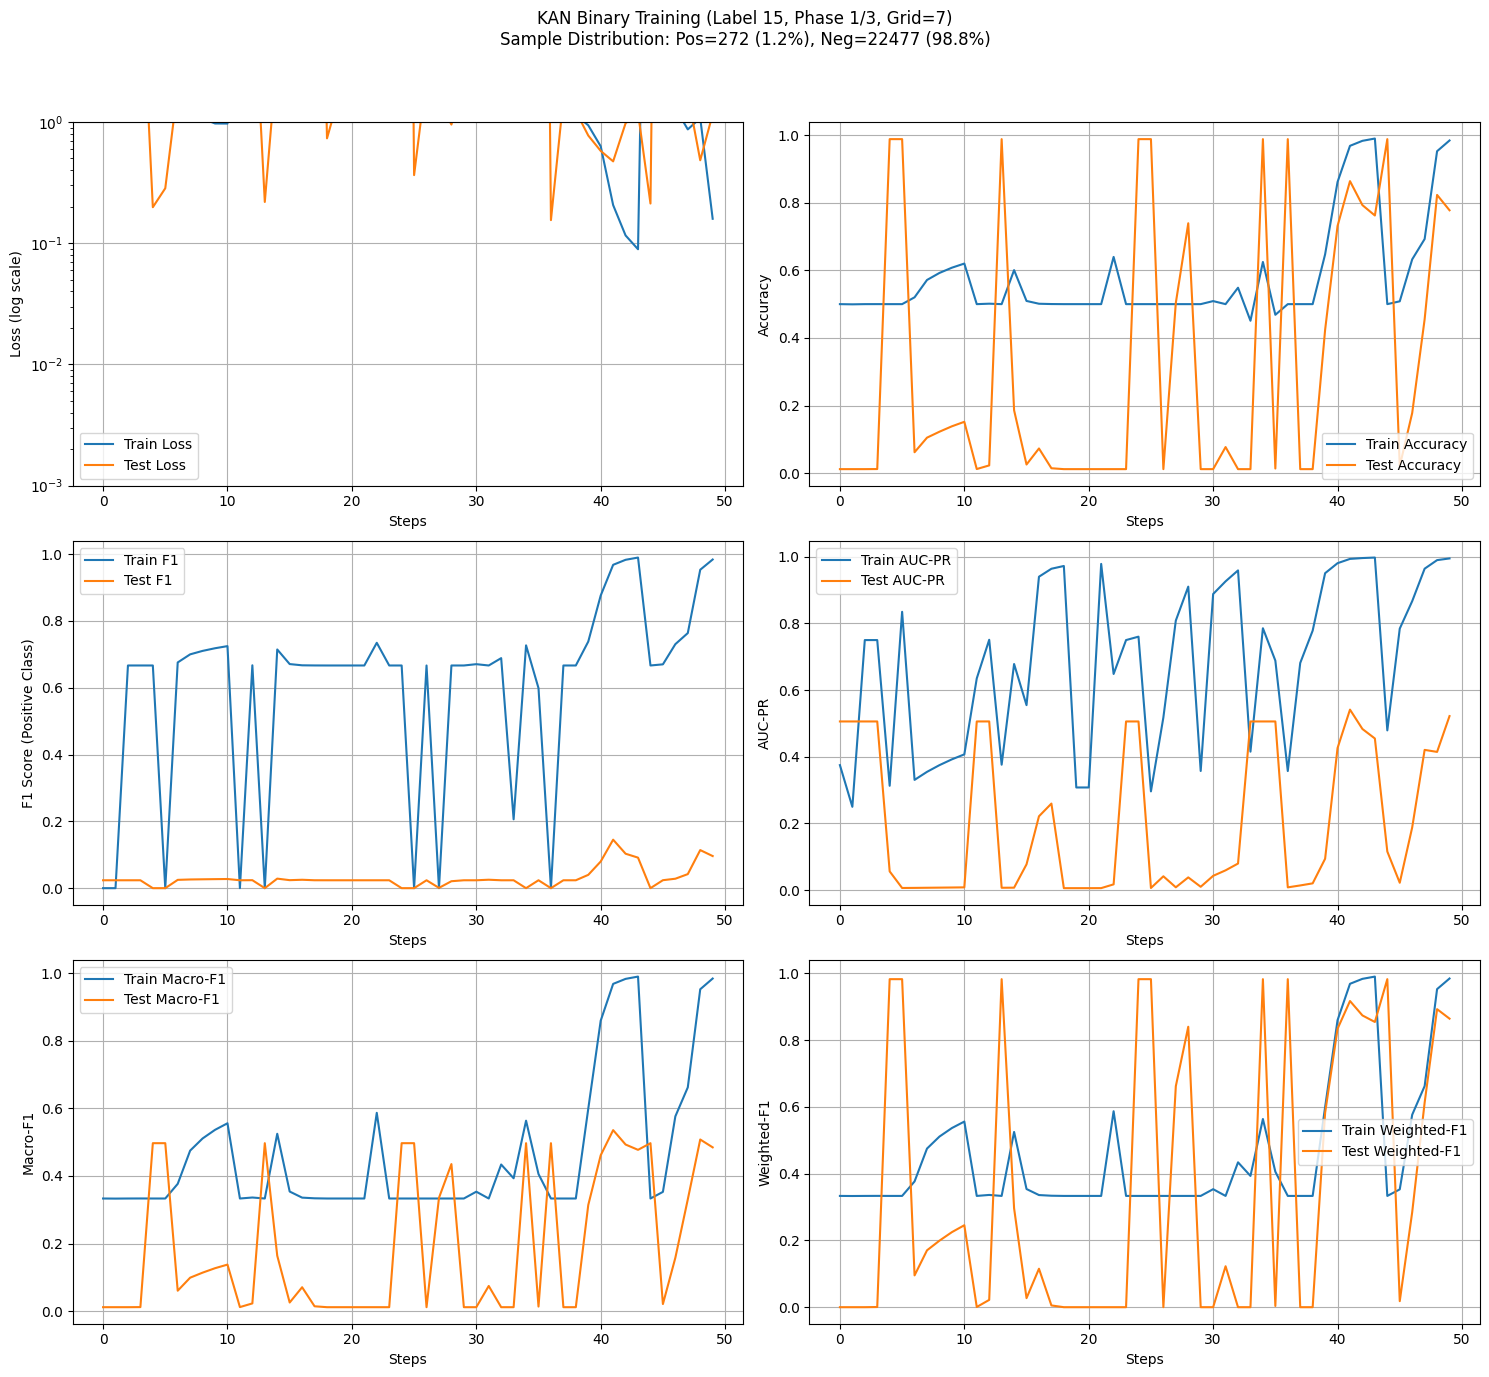


-- 网格点 5/11 (G=7), 步骤 26/50 --
训练损失: 0.159086, 测试损失: 1.159775
训练准确率: 0.9841, 测试准确率: 0.7776
正样本F1: 0.9839, 测试正样本F1: 0.0961
测试AUC-PR: 0.5221, Macro-F1: 0.4847, Weighted-F1: 0.8639
验证集样本: 正=272个, 负=22477个, 总计=22749个
验证集正样本比例: 1.20%, 负样本来自约 100 个其他标签
当前f1: 0.096123, 最佳f1: 0.145143, 无改善次数: 8/1000
样本分布: 正样本=272 (1.2%), 负样本=22477 (98.8%)
Grid 7: 31/50 (62.0%)
模型已全面保存到: /home/jovyan/gpu_space/workspace_jiayi/KAN training/brain_voxel_data/output/kan_models_binary/kan_brain_binary_label15_best
保存了新的最佳模型! f1=0.158363
训练损失: 0.155713, 测试损失: 0.509194
训练准确率: 0.9871, 测试准确率: 0.8752
正样本F1: 0.9870, 测试正样本F1: 0.1584
测试AUC-PR: 0.3173, Macro-F1: 0.5455, Weighted-F1: 0.9234


In [ ]:
# --------------------- 主脚本 ---------------------
# 可以根据需求选择执行以下代码块
import os
import numpy as np


# 打印配置信息
print("当前配置:")
config.print_config()

print("\n可选操作:")
print("1. 训练单个标签的模型")
print("2. 训练多个标签的模型")
print("3. 训练所有标签的模型")
print("4. 评估模型性能")
print("5. 使用模型进行预测")

choice = input("请选择操作 (1-5): ")

    
if choice == '1':
    # 训练单个标签的模型 (使用早停)
    label_id = int(input("请输入要训练的标签ID: "))
    
    # 配置早停参数
    patience = int(input("请输入早停耐心值 (默认10): ") or "10")
    min_delta = float(input("请输入最小改善量 (默认0.001): ") or "0.001")
    
    monitor_options = ['f1', 'accuracy', 'loss', 'auc_pr', 'macro_f1', 'weighted_f1']
    monitor_choice = input(f"请选择监控指标 ({'/'.join(monitor_options)}, 默认f1): ").lower()
    monitor = monitor_choice if monitor_choice in monitor_options else 'f1'
    
    print(f"开始训练标签 {label_id} 的模型 (早停设置: 耐心值={patience}, 最小改善={min_delta}, 监控={monitor})...")
    
    model, results = train_binary_model_for_label_with_early_stopping(
        label_id,
        patience=patience,
        min_delta=min_delta,
        monitor=monitor
    )
    
    if results is not None:
        final_metrics = results['final_metrics']
        print(f"训练完成! 标签 {label_id} 的最终指标:")
        print(f"  准确率: {final_metrics['accuracy']:.4f}")
        print(f"  F1分数(正样本): {final_metrics['f1']:.4f}")
        print(f"  精确度(正样本): {final_metrics['precision']:.4f}")
        print(f"  召回率(正样本): {final_metrics['recall']:.4f}")
        print(f"  AUC-PR: {final_metrics.get('auc_pr', 0):.4f}")
        print(f"  Macro-F1: {final_metrics.get('macro_f1', 0):.4f}")
        print(f"  Weighted-F1: {final_metrics.get('weighted_f1', 0):.4f}")
        print(f"  训练时间: {results['train_time']:.2f} 秒")
        print(f"  早停触发: {'是' if results.get('early_stopped', False) else '否'}")
        print(f"  最佳{monitor}: {results.get('best_score', 'N/A')}")


elif choice == '2':
    # 训练多个标签的模型 (使用早停)
    labels_input = input("请输入要训练的标签ID (用逗号分隔): ")
    
    # 配置早停参数
    patience = int(input("请输入早停耐心值 (默认10): ") or "10")
    min_delta = float(input("请输入最小改善量 (默认0.001): ") or "0.001")
    
    monitor_options = ['f1', 'accuracy', 'loss', 'auc_pr', 'macro_f1', 'weighted_f1']
    monitor_choice = input(f"请选择监控指标 ({'/'.join(monitor_options)}, 默认f1): ").lower()
    monitor = monitor_choice if monitor_choice in monitor_options else 'f1'
    
    try:
        selected_labels = [int(label.strip()) for label in labels_input.split(',')]
        print(f"开始训练以下标签的模型: {selected_labels}")
        print(f"早停设置: 耐心值={patience}, 最小改善={min_delta}, 监控={monitor}")
        
        overall_results = train_all_labels_with_early_stopping(
            training_labels=selected_labels,
            patience=patience,
            min_delta=min_delta,
            monitor=monitor
        )
    except ValueError:
        print("输入格式错误。请输入以逗号分隔的数字，如 '1,2,3'")

elif choice == '3':
    # 训练所有标签的模型 (使用早停)
    confirm = input("确定要训练所有有效标签吗? 这可能需要很长时间 (y/n): ")
    if confirm.lower() == 'y':
        # 配置早停参数
        patience = int(input("请输入早停耐心值 (默认10): ") or "10")
        min_delta = float(input("请输入最小改善量 (默认0.001): ") or "0.001")
        
        monitor_options = ['f1', 'accuracy', 'loss', 'auc_pr', 'macro_f1', 'weighted_f1']
        monitor_choice = input(f"请选择监控指标 ({'/'.join(monitor_options)}, 默认f1): ").lower()
        monitor = monitor_choice if monitor_choice in monitor_options else 'f1'
        
        print("开始训练所有标签的模型...")
        print(f"早停设置: 耐心值={patience}, 最小改善={min_delta}, 监控={monitor}")
        
        overall_results = train_all_labels_with_early_stopping(
            patience=patience,
            min_delta=min_delta,
            monitor=monitor
        )
    else:
        print("操作已取消")

elif choice == '4':
    # 评估模型性能
    print("加载验证数据...")
    val_data = np.load(f"{config.output_path}/val_data.npy")
    val_label = np.load(f"{config.output_path}/val_label.npy")
    
    # 限制评估样本数量以提高速度
    test_size_input = input("请输入评估样本数量 (默认1000): ")
    try:
        test_size = int(test_size_input) if test_size_input.strip() else 1000
    except ValueError:
        test_size = 1000
        print(f"输入格式错误，使用默认值 {test_size}")
    
    # 随机抽样
    indices = np.random.choice(val_data.shape[0], min(test_size, val_data.shape[0]), replace=False)
    test_data = val_data[indices]
    test_labels = val_label[indices]
    
    print(f"评估 {test_data.shape[0]} 个样本的模型性能...")
    results, all_predictions = evaluate_all_binary_models(
        model_dir=config.export_path,
        test_data=test_data,
        true_labels=test_labels,
        batch_size=100
    )
    
    print("评估完成!")

elif choice == '5':
    # 使用模型进行预测
    print("选项:")
    print("a. 使用验证数据进行预测")
    print("b. 提供自定义数据文件路径")
    
    sub_choice = input("请选择 (a/b): ")
    
    if sub_choice.lower() == 'a':
        print("加载验证数据...")
        val_data = np.load(f"{config.output_path}/val_data.npy")
        
        sample_count_input = input("请输入要预测的样本数量 (默认10): ")
        try:
            sample_count = int(sample_count_input) if sample_count_input.strip() else 10
        except ValueError:
            sample_count = 10
            print(f"输入格式错误，使用默认值 {sample_count}")
        
        # 选择样本
        new_samples = val_data[:min(sample_count, val_data.shape[0])]
        
        print(f"预测 {new_samples.shape[0]} 个样本...")
        regions, probabilities, binary_predictions = predict_brain_regions(
            input_data=new_samples,
            threshold=0.5
        )
        
        # 显示结果
        print("\n预测结果:")
        for i in range(new_samples.shape[0]):
            predicted_region = regions[i]
            region_prob = probabilities[i, predicted_region]
            print(f"样本 {i+1}: 预测脑区域 = {predicted_region}, 置信度 = {region_prob:.4f}")
            
            # 显示所有预测为1的区域
            positive_regions = np.where(binary_predictions[i] == 1)[0]
            if len(positive_regions) > 0:
                print(f"  预测为阳性的所有区域: {positive_regions}")
                print(f"  对应概率: {', '.join(f'{probabilities[i, r]:.4f}' for r in positive_regions)}")

            else:
                print(f"  没有区域预测为阳性")
        
        # 可视化预测结果
        visualize_binary_prediction_results(binary_predictions, probabilities)
        
    elif sub_choice.lower() == 'b':
        data_path = input("请输入数据文件路径 (.npy 格式): ")
        if os.path.exists(data_path) and data_path.endswith('.npy'):
            demo_prediction(data_path)
        else:
            print(f"错误: 文件 {data_path} 不存在或格式不正确")
    
    else:
        print("无效选择")

else:
    print("无效选择")

In [ ]:
# # --------------------- 示例1：训练单个标签 ---------------------
# # 训练单个标签的模型，例如训练标签ID为5的模型
# label_id = 5
# model, results = train_binary_model_for_label(label_id)

# # 如果训练成功，可以查看训练结果
# if results is not None:
#     final_metrics = results['final_metrics']
#     print(f"训练完成! 标签 {label_id} 的最终指标:")
#     print(f"  准确率: {final_metrics['accuracy']:.4f}")
#     print(f"  F1分数: {final_metrics['f1']:.4f}")
#     print(f"  精确度: {final_metrics['precision']:.4f}")
#     print(f"  召回率: {final_metrics['recall']:.4f}")
#     print(f"  训练时间: {results['train_time']:.2f} 秒")

# # --------------------- 示例2：训练多个标签 ---------------------
# # 选择要训练的标签
# selected_labels = [5, 10, 15, 20, 25]  # 自定义你想要训练的标签
# overall_results = train_all_labels(training_labels=selected_labels)

# # 或者训练所有标签
# # overall_results = train_all_labels()  # 这将训练所有有效标签

# # --------------------- 示例3：评估模型性能 ---------------------
# # 加载验证数据
# val_data = np.load(f"{config.output_path}/val_data.npy")
# val_label = np.load(f"{config.output_path}/val_label.npy")

# # 限制评估样本数量以提高速度
# test_size = 1000
# indices = np.random.choice(val_data.shape[0], test_size, replace=False)
# test_data = val_data[indices]
# test_labels = val_label[indices]

# # 评估模型性能
# results, all_predictions = evaluate_all_binary_models(
#     model_dir=config.export_path,
#     test_data=test_data,
#     true_labels=test_labels,
#     batch_size=100
# )

# # --------------------- 示例4：使用模型进行预测 ---------------------
# # 假设我们有一些新的未标记样本
# new_samples = test_data[:10]  # 示例中使用验证集的前10个样本

# # 预测脑区域
# regions, probabilities, binary_predictions = predict_brain_regions(
#     input_data=new_samples,
#     threshold=0.5
# )

# # 可视化预测结果
# visualize_binary_prediction_results(binary_predictions, probabilities)

# # --------------------- 示例5：单个模型加载和使用 ---------------------
# # 加载特定标签的最新模型
# model_folder = find_latest_model(config.export_path, label_id=5)
# if model_folder:
#     model, model_config = load_kan_model_folder(model_folder)
    
#     # 使用模型进行预测
#     test_sample = test_data[0:1]  # 单个样本
#     with torch.no_grad():
#         test_tensor = torch.from_numpy(test_sample).float().to(device)
#         output = model(test_tensor)
#         prob = torch.sigmoid(output).cpu().numpy()[0][0]
#         prediction = 1 if prob > 0.5 else 0
        
#     print(f"样本预测结果: 概率={prob:.4f}, 预测类别={prediction}")

In [ ]:
# # 测试加载完整模型
# model_complete, _ = load_model_comprehensive("/home/jannik/Documents/brain_voxel_data/output/kan_models_binary/kan_brain_binary_label1_final_label1_grid100_20250306_221139", method='complete')

# # 测试通过权重重建模型
# model_weights, _ = load_model_comprehensive("/home/jannik/Documents/brain_voxel_data/output/kan_models_binary/kan_brain_binary_label1_final_label1_grid100_20250306_221139", method='weights')

# # 验证两种加载方式都能正常工作
# test_input = torch.randn(1, 341).to(device)  # 创建随机输入
# with torch.no_grad():
#     output_complete = model_complete(test_input)
#     output_weights = model_weights(test_input)

# # 比较输出是否一致
# print(f"输出差异: {torch.abs(output_complete - output_weights).max().item()}")